# Compute Acquisition Functions.

## Prepare the notebook.

### Import libraries

In [295]:
import sys
import os
import yaml

from matplotlib import cm, colors
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


### Import extra moduels

In [296]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"
sys.path.insert(0, os.path.join(BASE_DIR, "scripts"))
from data_utils import get_protocol_tranformations

### Define paths and constants.

In [297]:
UNIQUE_CONC_H5AD = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/unique_concentrations_adata.h5ad"
CANDIDATES_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/results"
CANDIDATES_CSV = os.path.join(CANDIDATES_DIR, "all_candidates.csv")
ANNOTATION_CONFIG_PATH = os.path.join(
    BASE_DIR,
    "generative_modeling/conditional_flow_matching/config/annotation/default.yaml"
)
OUT_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/csv_files_new_targets"
CT_OF_INTEREST = [
    "HSCs",
    # "Pro-B",
    # "Early_Pro-B",
    # "DCs-CD14",
    # "CD14-Mono",
    "EryPro",
    # "EosBasoMastPre",
    # "EosBasoMastPre_2",
    "MgkPro",
    # "CyclingProgenitor*",
    # "GMP-Neutro",
    # "GMP-Neutro_CD16-Mono"
]
ONLY_CT_OF_INTEREST = True


### Read annotation dict.

In [298]:
with open(ANNOTATION_CONFIG_PATH, "r") as fb:
    annotation_config = yaml.safe_load(fb)
print(annotation_config.keys())

dict_keys(['protocol_columns', 'protocol_obs_key_added', 'protocol_sep', 'one_hot_uns_key_added', 'protocol_obsm_key', 'scatter_columns', 'base_sample_rep', 'scatter_obsm_key', 'concat_obsm_key', 'log1p_exp_cols', 'log21p_exp_cols'])


### Define Utility Functions.

In [299]:
def colored_histogram(
    df,
    x_col,
    color_col,
    bins=100,
    agg="mean",
    cmap_name="viridis",
    xlabel=None,
    ylabel="Count",
    colorbar_label=None,
    title=""
):
    """
    Plot a histogram of x_col with bin colors determined by aggregated values
    of color_col within each bin.

    Parameters
    ----------
    df : pandas.DataFrame
    x_col : str
        Column for histogram x-axis
    color_col : str
        Column used to color bins
    bins : int or sequence, default 100
    agg : {'mean', 'median', 'sum', 'min', 'max'}, default 'mean'
        Aggregation applied to color_col per bin
    cmap_name : str, default 'viridis'
    xlabel : str, optional
    ylabel : str, default 'Count'
    colorbar_label : str, optional
    """
    plt.figure(figsize=(3,3))
    plt.title(title)

    x = df[x_col].values
    c = df[color_col].values

    # Histogram
    counts, bin_edges = np.histogram(x, bins=bins)
    bin_ids = np.digitize(x, bin_edges) - 1

    # Aggregation function
    agg_funcs = {
        "mean": np.mean,
        "median": np.median,
        "sum": np.sum,
        "min": np.min,
        "max": np.max,
    }

    if agg not in agg_funcs:
        raise ValueError(f"agg must be one of {list(agg_funcs.keys())}")

    agg_func = agg_funcs[agg]

    # Aggregate color column per bin
    bin_color = np.array([
        agg_func(c[bin_ids == i]) if np.any(bin_ids == i) else np.nan
        for i in range(len(bin_edges) - 1)
    ])

    # Seaborn styling
    sns.set_theme(style="whitegrid")

    cmap = cm.get_cmap(cmap_name)
    norm = colors.Normalize(
        vmin=np.nanmin(bin_color),
        vmax=np.nanmax(bin_color)
    )

    # Plot
    plt.bar(
        bin_edges[:-1],
        counts,
        width=np.diff(bin_edges),
        align="edge",
        color=cmap(norm(bin_color)),
        edgecolor="none"
    )

    plt.xlabel(xlabel or x_col)
    plt.ylabel(ylabel)
    plt.show()


def get_distance_matrix(X, Y, metric="jensen-shannon"):
    """
    Compute KL divergence from each row in X to each row in Y.
    X: shape (N, D)
    Y: shape (K, D)
    Returns: shape (N, K)
    """
    eps = 1e-12
    X = np.clip(X, eps, 1)[:, None, :]
    Y = np.clip(Y, eps, 1)[None, :, :]
    if metric == "jensen-shannon":
        return np.sqrt(0.5*np.sum(X*np.log(2*X / (Y + X)), axis=-1) + 0.5*np.sum(Y*np.log(2*Y / (Y + X)), axis=-1))
    elif metric == "jeffrey":
        return 0.5*np.sum(X* np.log(X / Y), axis=-1) + 0.5*np.sum(Y* np.log(Y/ X), axis=-1)
    elif metric == "kl-div":
        return np.sum(X * np.log(X / Y), axis=-1) # WARNING: not a metric
    else:
        raise ValueError


def map_df(df, transforms_dict):
    transformed_data_df = {}
    for mol, trnsf in transforms_dict.items():
        val = df.loc[:, mol].values
        if trnsf is not None:
            val = trnsf(val)
        transformed_data_df[mol] = val
    return pd.DataFrame(transformed_data_df, index=df.index)


def get_g_star(ct, classes):
    # get target probability vector for current cell type
    ct_idx = classes.index(ct)
    g_star = np.zeros(len(classes))
    g_star[ct_idx] = 1.0
    return g_star[None]


def compute_exploitation_score(surr_candidates_vals):
    max_surr_loss_candidates = surr_candidates_vals.max()
    min_surr_loss_candidates = surr_candidates_vals.min()
    return (surr_candidates_vals - min_surr_loss_candidates) / (max_surr_loss_candidates - min_surr_loss_candidates)


def compute_exploration_score(Dct):
    candidates_nn_dist = Dct.min(1)
    max_nn_dist = candidates_nn_dist.max()
    min_nn_dist = candidates_nn_dist.min()
    return (max_nn_dist - candidates_nn_dist)/(max_nn_dist - min_nn_dist)
 

def compute_surr_exponential_weight(surr_candidates_vals, gamma=1.0):
    exploitation_score = compute_exploitation_score(surr_candidates_vals)
    return gamma*np.exp(-exploitation_score)


def compute_weighted_uncertainty_score(
    surr_candidates_vals, candidates_df, data_df, gamma=1.0
):
    exp_weight = compute_surr_exponential_weight(surr_candidates_vals, gamma=gamma) # N
    D_data = cdist(candidates_df.values, data_df.values) # N, M
    D_candidates = cdist(
        candidates_df.values, candidates_df.values
    ) # N, N
    U_data = D_data.min(1) # N
    U_concat_list = []
    for idx in range(D_candidates.shape[1]):
        D_concat = np.concatenate((D_data, D_candidates[:, idx][:, None]), axis=1) # N, M + 1
        U_concat = D_concat.min(1) # N 
        U_concat_list.append(U_concat)
    U_concat_arr = np.stack(U_concat_list, axis=0) # N, N
    return ((U_data[None] - U_concat_arr)*exp_weight[None]).mean(1)


### Prepare medium covariates transformations.

In [300]:
column2tranform = get_protocol_tranformations(
    annotation_config["protocol_columns"],
    log1p_exp_cols=annotation_config["log1p_exp_cols"],
    log21p_exp_cols=annotation_config["log21p_exp_cols"],
    inverse=False
)
len(column2tranform)
icolumn2tranform = get_protocol_tranformations(
    annotation_config["protocol_columns"],
    log1p_exp_cols=annotation_config["log1p_exp_cols"],
    log21p_exp_cols=annotation_config["log21p_exp_cols"],
    inverse=True
)
len(column2tranform)


15

## Load Candidate Solutions.

### Read candidates data.

In [301]:
candidates_df = pd.read_csv(CANDIDATES_CSV)
candidates_df.index = candidates_df["Unnamed: 0"]
candidates_df.index.name = "sample_id"
candidates_df = candidates_df.drop(["Unnamed: 0"], axis=1)
print(candidates_df.shape)
candidates_df.head()

(182925, 76)


,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],...,sampling:N,sampling:num_time_steps,sampling:solver_kwargs:method,sampling:sde_sampling,scheduler:scheduler_id,scheduler:scheduler_kwargs:lambda_val,scheduler:scheduler_kwargs:lmin,scheduler:scheduler_kwargs:lmax,scheduler:scheduler_kwargs:gamma,optimized_metric
sample_id,,,,,,,,,,,,,,,,,,,,,
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:0,5.762090,373.691350,1.949186,39.104477,0.741491,275.94617,1025.945700,0.000000,70.369690,0.000000,...,125,500,euler,False,constant,5.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:1,6.530979,40.365350,0.893951,7.466967,0.778309,4269.05000,28.230660,0.000000,100.322120,4.166629,...,125,500,euler,False,constant,5.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:2,1.755783,7.990452,195.405600,0.417799,6.574911,634.16095,1.949413,273.045230,1211.206300,4.094928,...,125,500,euler,False,constant,5.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:3,3.700521,15.408537,54.197260,2.219714,3.790896,947.43030,3308.386000,1.539189,49.824650,5.660841,...,125,500,euler,False,constant,5.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:4,5.274130,57.309658,10.156144,6.715555,2.272584,131.61038,1267.827100,0.000000,29.560978,0.484337,...,125,500,euler,False,constant,5.0,0.0,10.0,1.0,all_conditions_wasserstein_distance


### Get index for target cell types and prepare label encoder.

In [302]:
target_cell_types = candidates_df.index.map(lambda e: e.split(":")[0])
unique_cell_types = np.unique(target_cell_types)

# Prepare label encoder
ct_le = LabelEncoder()
ct_le.fit(target_cell_types)
classes = ct_le.classes_.tolist()
classes

['CD14-Mono',
 'CD49c-Myeloid',
 'CyclingProgenitor*',
 'DCs-CD14',
 'EarlyGMP',
 'Early_Pro-B',
 'EosBasoMastPre',
 'EosBasoMastPre_2',
 'EryPro',
 'GMP-Cycle',
 'GMP-Neutro',
 'GMP-Neutro_CD16-Mono',
 'HSCs',
 'MEP',
 'MLP',
 'MPP',
 'MgkPro',
 'Pro-B',
 'pDCs_cDCs']

### Transform candidates.

In [303]:
transformed_candidates_df = map_df(candidates_df, column2tranform)
transformed_candidates_df.head()

,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
sample_id,,,,,,,,,,,,,,,
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:0,5.762090,5.926103,1.081529,3.691488,0.800323,5.623823,6.934344,0.000000,4.267873,0.000000,0.000000,0.000000,0.000000,2.082482,1.811672
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:1,6.530979,3.722444,0.638665,2.136172,0.830506,8.359381,3.375218,0.000000,4.618305,1.642220,0.375170,13.001043,0.000000,2.119837,0.611545
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:2,1.755783,2.196163,5.280182,0.349106,2.921229,6.453878,1.081606,5.613293,7.100197,1.628246,1.080145,1.102836,1.942828,3.246203,2.802647
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:3,3.700521,2.797802,4.010913,1.169292,2.260296,6.854808,8.104518,0.931845,3.928381,1.896246,0.000000,0.180974,0.000000,2.878357,3.323007
Early_Pro-B:2025-12-20_22-02-43_1b38fbbc:4,5.274130,4.065768,2.411990,2.043238,1.710430,4.887415,7.145848,0.000000,3.419724,0.394968,0.000000,0.036934,0.000000,3.243362,2.745763


## Load Measured Concentrations.

### Unique concentrations.

In [304]:
conc_adata = sc.read_h5ad(UNIQUE_CONC_H5AD)
conc_adata

AnnData object with n_obs × n_vars = 117 × 15
    obs: 'CD14-Mono', 'CD49c-Myeloid', 'CyclingProgenitor', 'DCs-CD14', 'EarlyGMP', 'Early_Pro-B', 'EosBasoMastPre', 'EosBasoMastPre_2', 'EryPro', 'GMP-Cycle', 'GMP-Neutro', 'GMP-Neutro_CD16-Mono', 'HSCs', 'MEP', 'MLP', 'MPP', 'MgkPro', 'Pro-B', 'pDCs_cDCs'

### Inverse Transformation on data concentrations.

In [305]:
transformed_data_conc_df = pd.DataFrame(
    conc_adata.X,
    columns=conc_adata.var_names,
    index=conc_adata.obs.index
)
data_conc_df = map_df(transformed_data_conc_df, icolumn2tranform)
data_conc_df

,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
0,5.0,100.0,10.0,0.0,0.0,0.0,0.0,1.5,0.0,100.0,0.0,0.0,0.0,20.0,13.0
1,5.0,100.0,10.0,0.0,0.0,0.0,0.0,1.5,0.0,100.0,0.0,0.0,0.0,20.0,14.0
2,5.0,100.0,10.0,0.0,0.0,0.0,0.0,1.5,0.0,100.0,0.0,0.0,0.0,20.0,15.0
3,5.0,100.0,10.0,0.0,0.0,0.0,0.0,1.5,0.0,100.0,0.0,0.0,0.0,20.0,21.0
4,5.0,100.0,10.0,0.0,0.0,0.0,70.0,0.0,0.0,100.0,0.0,0.0,0.0,20.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,5.0,100.0,10.0,10.0,2.5,750.0,1120.0,0.0,50.0,0.0,1.0,0.0,0.0,20.0,14.0
113,5.0,100.0,10.0,10.0,2.5,750.0,1120.0,0.0,50.0,0.0,1.0,0.0,0.0,20.0,21.0
114,5.0,100.0,10.0,10.0,2.5,750.0,1120.0,0.0,50.0,0.0,5.0,0.0,0.0,20.0,14.0
115,5.0,100.0,10.0,10.0,2.5,750.0,1120.0,0.0,50.0,0.0,5.0,0.0,0.0,20.0,21.0


### Compute bounds.

In [306]:
ubound = data_conc_df.max(0).values
lbound = data_conc_df.min(0).values

### Compute distance from candidates concentrations to measured ones.

In [307]:
X_conc_candidates = transformed_candidates_df.values
X_conc_data = conc_adata.X
D = cdist(X_conc_candidates, X_conc_data)
D.shape

(182925, 117)

### Evaluate loss on measured conditions.

In [308]:
# data_losses = {}
# for ct in unique_cell_types:
#     if ct not in CT_OF_INTEREST and ONLY_CT_OF_INTEREST:
#         continue
#     # compute loss for data
#     g_star = get_g_star(ct, classes)
#     data_loss = -np.sum(g_star*np.log(conc_adata.obs[unique_cell_types]), axis=1)
#     data_losses[ct] = data_loss
# data_losses = pd.DataFrame(data_losses)
# data_losses.head()

### Display distribution of loss over conditions per cell type.

In [309]:
# long_df = data_losses.melt(var_name="CellType", value_name="Value")
# g = sns.FacetGrid(
#     long_df,
#     col="CellType",
#     col_wrap=4,      # 4 plots per row (adjust as needed)
#     sharex=True,
#     sharey=True,
#     height=2
# )
# g.map_dataframe(sns.histplot, x="Value", bins=20, kde=True)
# g.set_titles("{col_name}")
# g.set_axis_labels("Value", "Density")
# plt.tight_layout()
# plt.show()


## Metric Response Function Acquisition Function.

### Compute acquisition function.

In [310]:
exploration_exploitation_df = []
for ct in unique_cell_types:
    if ct not in CT_OF_INTEREST and ONLY_CT_OF_INTEREST:
        continue
    # get target probability vector for current cell type
    g_star = get_g_star(ct, classes)

    # compute loss for data
    # data_loss = -np.sum(g_star*np.log(conc_adata.obs[unique_cell_types]), axis=1)
    # data_losses[ct] = data_loss

    # compute mask
    ct_mask = target_cell_types == ct
    is_finite_mask = np.isfinite(candidates_df["loss"].values)
    ct_mask = ct_mask & is_finite_mask

    # get current results
    Dct = D[ct_mask]
    ct_candidates = transformed_candidates_df.iloc[ct_mask]
    surr_candidates_vals = candidates_df.iloc[ct_mask]["loss"].values

    # compute exploitation and exploration scores
    exploitation_score = compute_exploitation_score(surr_candidates_vals)
    exploration_score = compute_exploration_score(Dct)
    
    # store the results
    ct_eval_df = pd.DataFrame(
        {
            "exploration_score": exploration_score,
            "exploitation_score": exploitation_score,
            "target_ct": ct_candidates.index.map(lambda e: ct)
        },
        index=ct_candidates.index
    )
    exploration_exploitation_df.append(ct_eval_df)
exploration_exploitation_df = pd.concat(exploration_exploitation_df, axis=0)
exploration_exploitation_df.head()

,exploration_score,exploitation_score,target_ct
sample_id,,,
EryPro:2025-12-21_07-39-00_3d6c6e9b:0,0.779905,0.012094,EryPro
EryPro:2025-12-21_07-39-00_3d6c6e9b:1,0.682776,0.129575,EryPro
EryPro:2025-12-21_07-39-00_3d6c6e9b:2,0.502083,0.162406,EryPro
EryPro:2025-12-21_07-39-00_3d6c6e9b:3,0.834995,0.154863,EryPro
EryPro:2025-12-21_07-39-00_3d6c6e9b:4,0.838512,0.025118,EryPro


### Aggregate mettics


In [311]:
beta_vals = np.linspace(0.0, 1.0, 100)
scores = []
for beta in beta_vals:
    score = exploration_exploitation_df["exploration_score"].values*beta + (1 - beta)*exploration_exploitation_df["exploitation_score"].values
    exploration_exploitation_df[f"MRS_{beta}"] = score
    scores.append(score)
agg_scores = np.stack(scores, axis=1).mean(1)
exploration_exploitation_df[f"MRS_mean"] = agg_scores
exploration_exploitation_df.head()

/tmp/ipykernel_3813120/2351855411.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  exploration_exploitation_df[f"MRS_{beta}"] = score
/tmp/ipykernel_3813120/2351855411.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  exploration_exploitation_df[f"MRS_{beta}"] = score
/tmp/ipykernel_3813120/2351855411.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To 

,exploration_score,exploitation_score,target_ct,MRS_0.0,MRS_0.010101010101010102,MRS_0.020202020202020204,MRS_0.030303030303030304,MRS_0.04040404040404041,MRS_0.05050505050505051,MRS_0.06060606060606061,...,MRS_0.9191919191919192,MRS_0.9292929292929294,MRS_0.9393939393939394,MRS_0.9494949494949496,MRS_0.9595959595959597,MRS_0.9696969696969697,MRS_0.9797979797979799,MRS_0.98989898989899,MRS_1.0,MRS_mean
sample_id,,,,,,,,,,,,,,,,,,,,,
EryPro:2025-12-21_07-39-00_3d6c6e9b:0,0.779905,0.012094,EryPro,0.012094,0.019850,0.027606,0.035361,0.043117,0.050873,0.058628,...,0.717860,0.725616,0.733371,0.741127,0.748883,0.756638,0.764394,0.772150,0.779905,0.396000
EryPro:2025-12-21_07-39-00_3d6c6e9b:1,0.682776,0.129575,EryPro,0.129575,0.135163,0.140751,0.146338,0.151926,0.157514,0.163102,...,0.638073,0.643660,0.649248,0.654836,0.660424,0.666012,0.671600,0.677188,0.682776,0.406175
EryPro:2025-12-21_07-39-00_3d6c6e9b:2,0.502083,0.162406,EryPro,0.162406,0.165838,0.169269,0.172700,0.176131,0.179562,0.182993,...,0.474635,0.478066,0.481497,0.484928,0.488359,0.491790,0.495221,0.498652,0.502083,0.332245
EryPro:2025-12-21_07-39-00_3d6c6e9b:3,0.834995,0.154863,EryPro,0.154863,0.161733,0.168603,0.175473,0.182343,0.189213,0.196083,...,0.780035,0.786905,0.793775,0.800645,0.807515,0.814385,0.821255,0.828125,0.834995,0.494929
EryPro:2025-12-21_07-39-00_3d6c6e9b:4,0.838512,0.025118,EryPro,0.025118,0.033334,0.041550,0.049766,0.057982,0.066198,0.074414,...,0.772783,0.780999,0.789216,0.797432,0.805648,0.813864,0.822080,0.830296,0.838512,0.431815


### Display metrics.

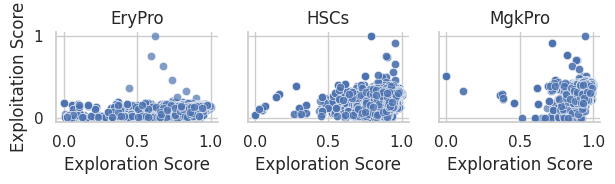

In [312]:
# Use FacetGrid to plot exploration vs exploitation per cell type
g = sns.FacetGrid(exploration_exploitation_df, col="target_ct", col_wrap=6, height=2, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="exploration_score", y="exploitation_score", alpha=0.7)
g.set_axis_labels("Exploration Score", "Exploitation Score")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()


### Display Scores.

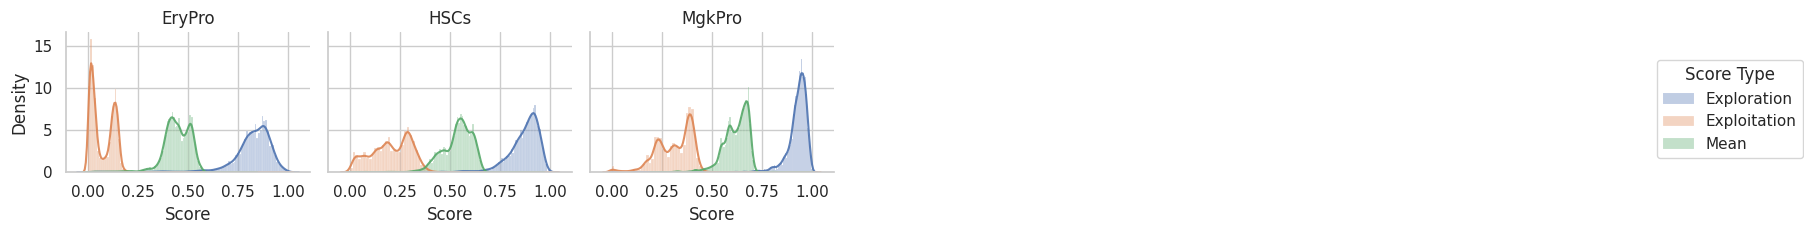

In [313]:
# Long format with a score_type column
score_long = exploration_exploitation_df.melt(
    id_vars=["target_ct"],
    value_vars=["exploration_score", "exploitation_score", "MRS_mean"],
    var_name="score_type",
    value_name="score"
)

# Optional: clean names for legend
score_long["score_type"] = score_long["score_type"].replace({
    "exploration_score": "Exploration",
    "exploitation_score": "Exploitation",
    "MRS_mean": "Mean"
})

# FacetGrid
g = sns.FacetGrid(
    score_long,
    col="target_ct",
    col_wrap=6,
    height=2.5,
    sharex=True,
    sharey=True,
    hue="score_type"
)

# Histogram
g.map_dataframe(
    sns.histplot,
    x="score",
    stat="density",
    fill=True,
    alpha=0.35,
    common_norm=False
)

# KDE
g.map_dataframe(
    sns.kdeplot,
    x="score",
    alpha=0.9,
    common_norm=False
)

# Labels & titles
g.set_axis_labels("Score", "Density")
g.set_titles(col_template="{col_name}")

# Force legend and move it slightly to the right
g.add_legend(title="Score Type")
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(True)
plt.tight_layout()
plt.show()


### Plot aggregated metrics along interpolation values.

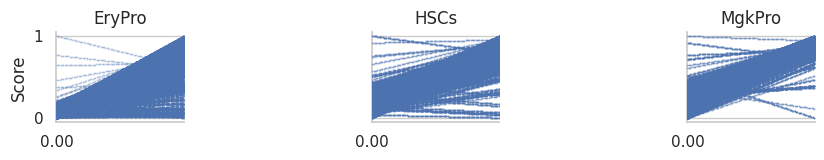

In [314]:
# Select interpolation score columns
score_cols = [c for c in exploration_exploitation_df.columns if c.startswith("MRS_") and "mean" not in c]

# Long format
long_scores = exploration_exploitation_df[score_cols].reset_index().melt(
    id_vars="sample_id",
    var_name="interp",
    value_name="score"
)

# Extract numeric interpolation value
long_scores["interp"] = long_scores["interp"].str.replace("MRS_", "").astype(float)

# Add cell type
long_scores = long_scores.merge(
    exploration_exploitation_df[["target_ct"]],
    left_on="sample_id",
    right_index=True
)

# Sort interpolation values
long_scores = long_scores.sort_values("interp")

# Wider FacetGrid
g = sns.FacetGrid(
    long_scores,
    col="target_ct",
    col_wrap=4,      # fewer columns → wider plots
    height=2,        # taller
    aspect=1.5,      # much wider
    sharey=True
)

# Vertical point columns
g.map_dataframe(
    sns.stripplot,
    x="interp",
    y="score",
    jitter=0.15,
    size=1.3,
    alpha=0.35
)

# Clean x-axis: only show a subset of ticks
for ax in g.axes.flat:
    xticks = ax.get_xticks()
    ax.set_xticks(xticks[::10])   # show every 10th interpolation weight
    ax.set_xticklabels([f"{t:.2f}" for t in xticks[::10]], rotation=0)
    ax.set_xlabel("")

g.set_axis_labels("", "Score")
g.set_titles("{col_name}")


## Box Constraints.

### Flag cells passing box constraints for some tolerance offset on the upper bound.

In [315]:
offsets = [0.0, 0.1, 0.25, 0.5, 1.0, 2.5, 5.0, 10.0]
for offset in offsets:
    exploration_exploitation_df[f"constraint_{offset}"] = np.all(candidates_df[annotation_config["protocol_columns"]] <= ubound + offset, axis=1)
exploration_exploitation_df.head()

/tmp/ipykernel_3813120/4268177169.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  exploration_exploitation_df[f"constraint_{offset}"] = np.all(candidates_df[annotation_config["protocol_columns"]] <= ubound + offset, axis=1)
/tmp/ipykernel_3813120/4268177169.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  exploration_exploitation_df[f"constraint_{offset}"] = np.all(candidates_df[annotation_config["protocol_columns"]] <= ubound + offset, axis=1)
/tmp/ipykernel_3813120/4268177169.py:3: PerformanceWarning: DataFrame is highl

,exploration_score,exploitation_score,target_ct,MRS_0.0,MRS_0.010101010101010102,MRS_0.020202020202020204,MRS_0.030303030303030304,MRS_0.04040404040404041,MRS_0.05050505050505051,MRS_0.06060606060606061,...,MRS_1.0,MRS_mean,constraint_0.0,constraint_0.1,constraint_0.25,constraint_0.5,constraint_1.0,constraint_2.5,constraint_5.0,constraint_10.0
sample_id,,,,,,,,,,,,,,,,,,,,,
EryPro:2025-12-21_07-39-00_3d6c6e9b:0,0.779905,0.012094,EryPro,0.012094,0.019850,0.027606,0.035361,0.043117,0.050873,0.058628,...,0.779905,0.396000,False,False,False,False,False,False,False,False
EryPro:2025-12-21_07-39-00_3d6c6e9b:1,0.682776,0.129575,EryPro,0.129575,0.135163,0.140751,0.146338,0.151926,0.157514,0.163102,...,0.682776,0.406175,False,False,False,False,False,False,False,False
EryPro:2025-12-21_07-39-00_3d6c6e9b:2,0.502083,0.162406,EryPro,0.162406,0.165838,0.169269,0.172700,0.176131,0.179562,0.182993,...,0.502083,0.332245,False,False,False,False,False,False,False,False
EryPro:2025-12-21_07-39-00_3d6c6e9b:3,0.834995,0.154863,EryPro,0.154863,0.161733,0.168603,0.175473,0.182343,0.189213,0.196083,...,0.834995,0.494929,False,False,False,False,False,False,False,False
EryPro:2025-12-21_07-39-00_3d6c6e9b:4,0.838512,0.025118,EryPro,0.025118,0.033334,0.041550,0.049766,0.057982,0.066198,0.074414,...,0.838512,0.431815,False,False,False,False,False,False,False,False


### Plot proportion of solutions satisfying constraints for each tolerance.


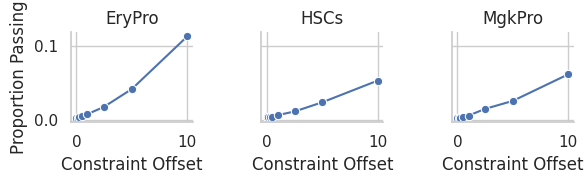

In [316]:
# Select constraint columns
constraint_cols = [c for c in exploration_exploitation_df.columns if c.startswith("constraint_")]

# Long format
long_df = exploration_exploitation_df[constraint_cols].reset_index().melt(
    id_vars="sample_id",
    var_name="constraint",
    value_name="passes"
)

# Extract numeric offset
long_df["offset"] = long_df["constraint"].str.replace("constraint_", "").astype(float)

# Add target_ct for faceting
long_df = long_df.merge(
    exploration_exploitation_df[["target_ct"]],
    left_on="sample_id",
    right_index=True
)

# Compute proportions
prop_df = (
    long_df
    .groupby(["target_ct", "offset"])["passes"]
    .mean()
    .reset_index(name="proportion")
)

# Plot with FacetGrid
g = sns.FacetGrid(prop_df, col="target_ct", col_wrap=4, height=2, sharey=True)
g.map_dataframe(
    sns.lineplot,
    x="offset",
    y="proportion",
    marker="o"
)

g.set_axis_labels("Constraint Offset", "Proportion Passing")
g.set_titles("{col_name}")


## Weighted Model Uncertainty Acquisition Function.

### Compute acquisition function.

In [317]:
gammas = [0.0, 0.1, 0.25, 0.5, 1.0]
wmu_dfs = []
for ct in tqdm(unique_cell_types):
    # skipping cell types
    if ct not in CT_OF_INTEREST and ONLY_CT_OF_INTEREST:
        continue

    # compute mask
    ct_mask = target_cell_types == ct
    is_finite_mask = np.isfinite(candidates_df["loss"].values)
    ct_mask = ct_mask & is_finite_mask

    # get current results
    ct_candidates = transformed_candidates_df.iloc[ct_mask]
    surr_candidates_vals = candidates_df.iloc[ct_mask]["loss"].values
    ct_wmus_df = pd.DataFrame(
        {
            f"wmus_{1 + gamma}": compute_weighted_uncertainty_score(
                surr_candidates_vals,
                ct_candidates,
                transformed_data_conc_df,
                gamma=1.0 + gamma
            ) for gamma in gammas
        },
        index=ct_candidates.index
    )
    wmu_dfs.append(ct_wmus_df)
wmu_dfs = pd.concat(wmu_dfs, axis=0)
wmu_dfs

  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [05:13<00:00, 16.52s/it]


,wmus_1.0,wmus_1.1,wmus_1.25,wmus_1.5,wmus_2.0
sample_id,,,,,
EryPro:2025-12-21_07-39-00_3d6c6e9b:0,0.067011,0.073712,0.083764,0.100516,0.134022
EryPro:2025-12-21_07-39-00_3d6c6e9b:1,0.006031,0.006634,0.007539,0.009047,0.012062
EryPro:2025-12-21_07-39-00_3d6c6e9b:2,0.005270,0.005797,0.006588,0.007905,0.010541
EryPro:2025-12-21_07-39-00_3d6c6e9b:3,0.002712,0.002983,0.003390,0.004068,0.005423
EryPro:2025-12-21_07-39-00_3d6c6e9b:4,0.028415,0.031257,0.035519,0.042623,0.056830
...,...,...,...,...,...
MgkPro:2025-12-20_22-38-21_6c0e8a2c:120,0.006312,0.006943,0.007890,0.009468,0.012624
MgkPro:2025-12-20_22-38-21_6c0e8a2c:121,0.008704,0.009575,0.010880,0.013056,0.017409
MgkPro:2025-12-20_22-38-21_6c0e8a2c:122,0.015883,0.017471,0.019854,0.023824,0.031766


### Distribution of Weighted Model Uncertainty score per target cell type and gamma value.

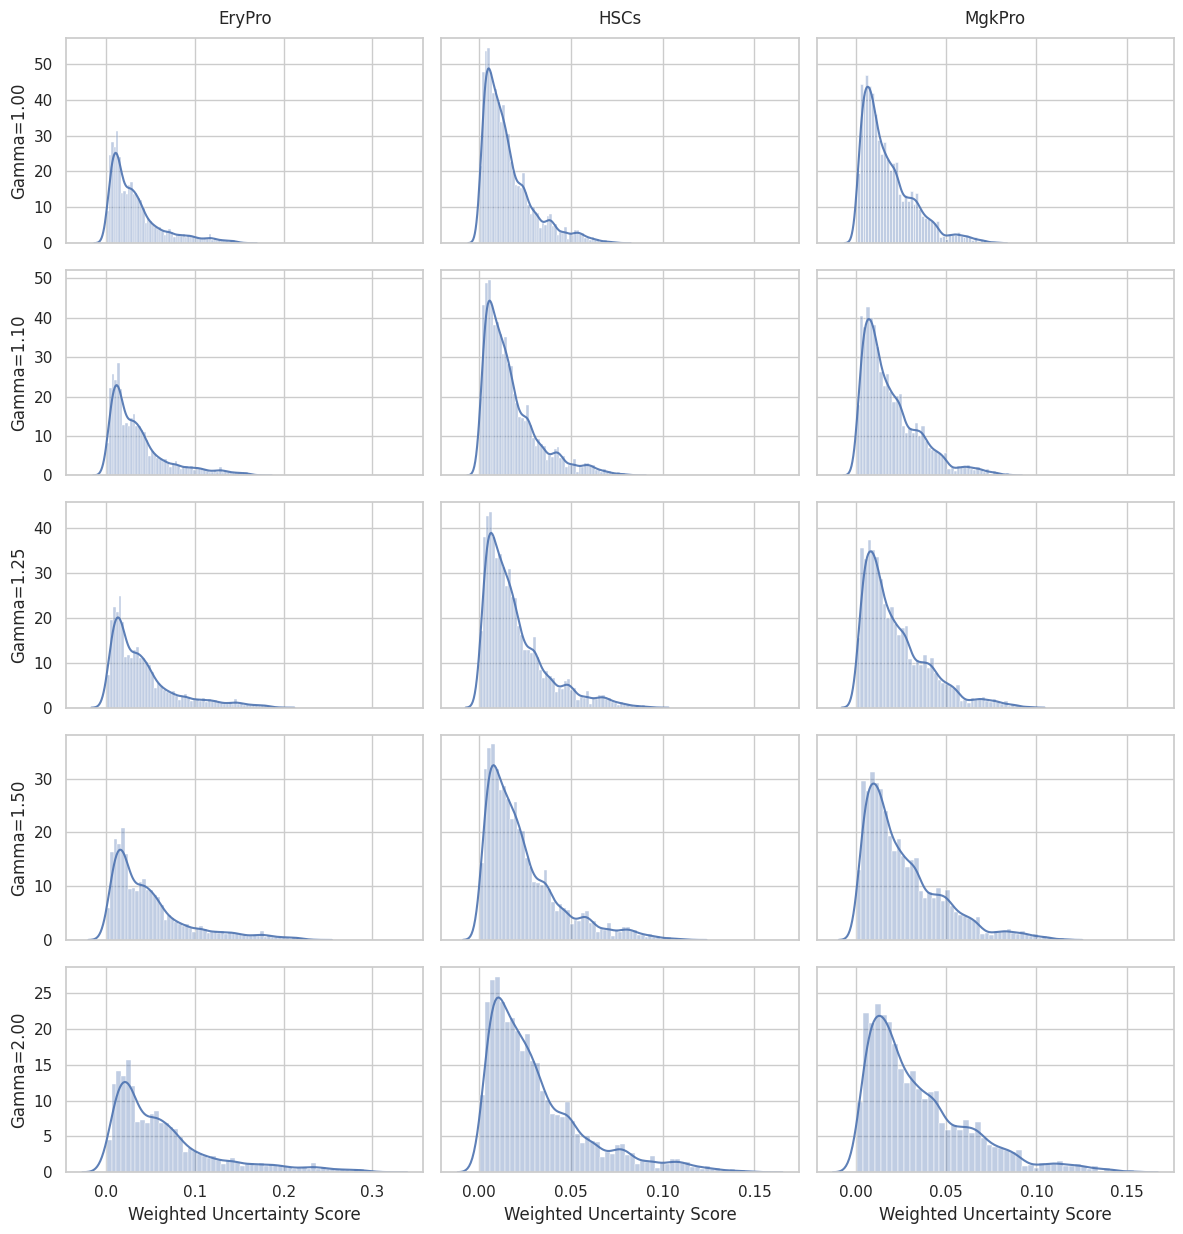

In [318]:
# Long format for wmu scores
wmu_long = wmu_dfs.reset_index().rename(columns={"index": "sample_id"}).melt(
    id_vars="sample_id",
    var_name="gamma",
    value_name="wmus"
)
wmu_long["gamma"] = wmu_long["gamma"].str.replace("wmus_", "").astype(float)

# Merge cell type info
if "target_ct" in exploration_exploitation_df.columns:
    wmu_long = wmu_long.merge(
        exploration_exploitation_df[["target_ct"]],
        left_on="sample_id",
        right_index=True
    )
else:
    wmu_long["target_ct"] = "All"

# Unique cell types and gammas
cell_types = wmu_long["target_ct"].unique()
gammas = sorted(wmu_long["gamma"].unique())

# Create figure: rows = gamma, columns = cell type
fig, axes = plt.subplots(
    nrows=len(gammas),
    ncols=len(cell_types),
    figsize=(4*len(cell_types), 2.5*len(gammas)),
    sharex='col',
    sharey='row'
)

# Ensure axes is 2D array even if single row/col
if len(gammas) == 1:
    axes = axes[None, :]
if len(cell_types) == 1:
    axes = axes[:, None]

# Plot each gamma in its own row per cell type
for i, gamma in enumerate(gammas):
    for j, ct in enumerate(cell_types):
        ax = axes[i, j]
        subset = wmu_long[(wmu_long["target_ct"] == ct) & (wmu_long["gamma"] == gamma)]
        sns.histplot(subset["wmus"], stat="density", fill=True, alpha=0.35, ax=ax)
        sns.kdeplot(subset["wmus"], ax=ax, alpha=0.9)

        # Only label x-axis at bottom row
        if i == len(gammas)-1:
            ax.set_xlabel("Weighted Uncertainty Score")
        else:
            ax.set_xlabel("")

        # Only label y-axis at first column
        if j == 0:
            ax.set_ylabel(f"Gamma={gamma:.2f}")
        else:
            ax.set_ylabel("")

# Add top titles for cell types
for j, ct in enumerate(cell_types):
    axes[0, j].set_title(ct, fontsize=12, pad=10)

plt.tight_layout()
plt.show()


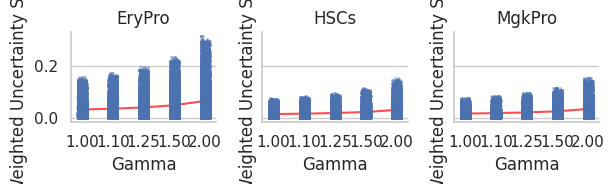

In [319]:
# Prepare long format
wmu_long = wmu_dfs.reset_index().rename(columns={"index": "sample_id"}).melt(
    id_vars="sample_id",
    var_name="gamma",
    value_name="wmus"
)
wmu_long["gamma"] = wmu_long["gamma"].str.replace("wmus_", "").astype(float)

# Merge cell type info
if "target_ct" in exploration_exploitation_df.columns:
    wmu_long = wmu_long.merge(
        exploration_exploitation_df[["target_ct"]],
        left_on="sample_id",
        right_index=True
    )
else:
    wmu_long["target_ct"] = "All"

# Convert gamma to string for categorical x
wmu_long["gamma_label"] = wmu_long["gamma"].apply(lambda x: f"{x:.2f}")

# FacetGrid: one column per cell type
g = sns.FacetGrid(
    wmu_long,
    col="target_ct",
    col_wrap=6,  # adjust for wide plots
    height=2,
    sharey=True
)

# Stripplot: vertical points for each gamma
g.map_dataframe(
    sns.stripplot,
    x="gamma_label",
    y="wmus",
    jitter=0.15,
    size=2,
    alpha=0.5
)

# Optionally, overlay a mean or median line per gamma
import numpy as np
def plot_means(data, **kwargs):
    ax = plt.gca()
    means = data.groupby("gamma_label")["wmus"].mean()
    ax.plot(means.index, means.values, color="red", marker="o", linestyle="-", alpha=0.7)

g.map_dataframe(plot_means)

# Clean x-axis
for ax in g.axes.flat:
    ax.set_xlabel("Gamma")
    ax.set_ylabel("Weighted Uncertainty Score")

g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()


## Select best samples.

### Concatenate evaluation df.

In [320]:
concat_df = pd.concat((candidates_df, exploration_exploitation_df, wmu_dfs), join="inner", axis=1)
concat_df.head()

,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],...,constraint_0.5,constraint_1.0,constraint_2.5,constraint_5.0,constraint_10.0,wmus_1.0,wmus_1.1,wmus_1.25,wmus_1.5,wmus_2.0
sample_id,,,,,,,,,,,,,,,,,,,,,
MgkPro:2025-12-20_13-04-29_93e9290b:0,4.794640,560.850500,0.042329,66.272736,0.515312,460.217000,852.786740,0.000000,10.125092,0.000000,...,False,False,False,False,False,0.025266,0.027793,0.031583,0.037900,0.050533
MgkPro:2025-12-20_13-04-29_93e9290b:1,6.530585,103.111260,4.212913,37.411766,0.540602,1987.987000,2502.452600,0.000000,71.788540,2.518846,...,False,False,False,False,False,0.003960,0.004356,0.004950,0.005940,0.007920
MgkPro:2025-12-20_13-04-29_93e9290b:2,3.320963,59.368977,7.879268,25.568302,2.861100,1127.131500,0.379402,463.516420,140.160460,0.000000,...,False,False,False,False,False,0.008008,0.008809,0.010011,0.012013,0.016017
MgkPro:2025-12-20_13-04-29_93e9290b:3,3.492704,156.494800,6.937639,5.130714,0.227772,3.149274,46.039230,0.249841,0.000000,90.609566,...,False,False,False,False,False,0.013072,0.014379,0.016340,0.019608,0.026143
MgkPro:2025-12-20_13-04-29_93e9290b:4,4.937889,149.577470,11.886740,1.622801,0.480793,2.342850,188.932970,0.000000,0.000000,36.030266,...,False,False,False,False,False,0.014947,0.016442,0.018684,0.022420,0.029894


### Filter data for each constrained and cell type.

In [321]:
ct_constrained_results = {} 
for target_ct, ct_idxs in concat_df.groupby(by="target_ct").groups.items():
    ct_concat_df = concat_df.loc[ct_idxs]
    ct_constrained_results[target_ct] = {
        e: ct_concat_df.iloc[ct_concat_df.loc[:, e].values] for e in ct_concat_df.columns if e.startswith("constraint_")
    }

### Plot distribution of MRS scores over samples satifying constraints.

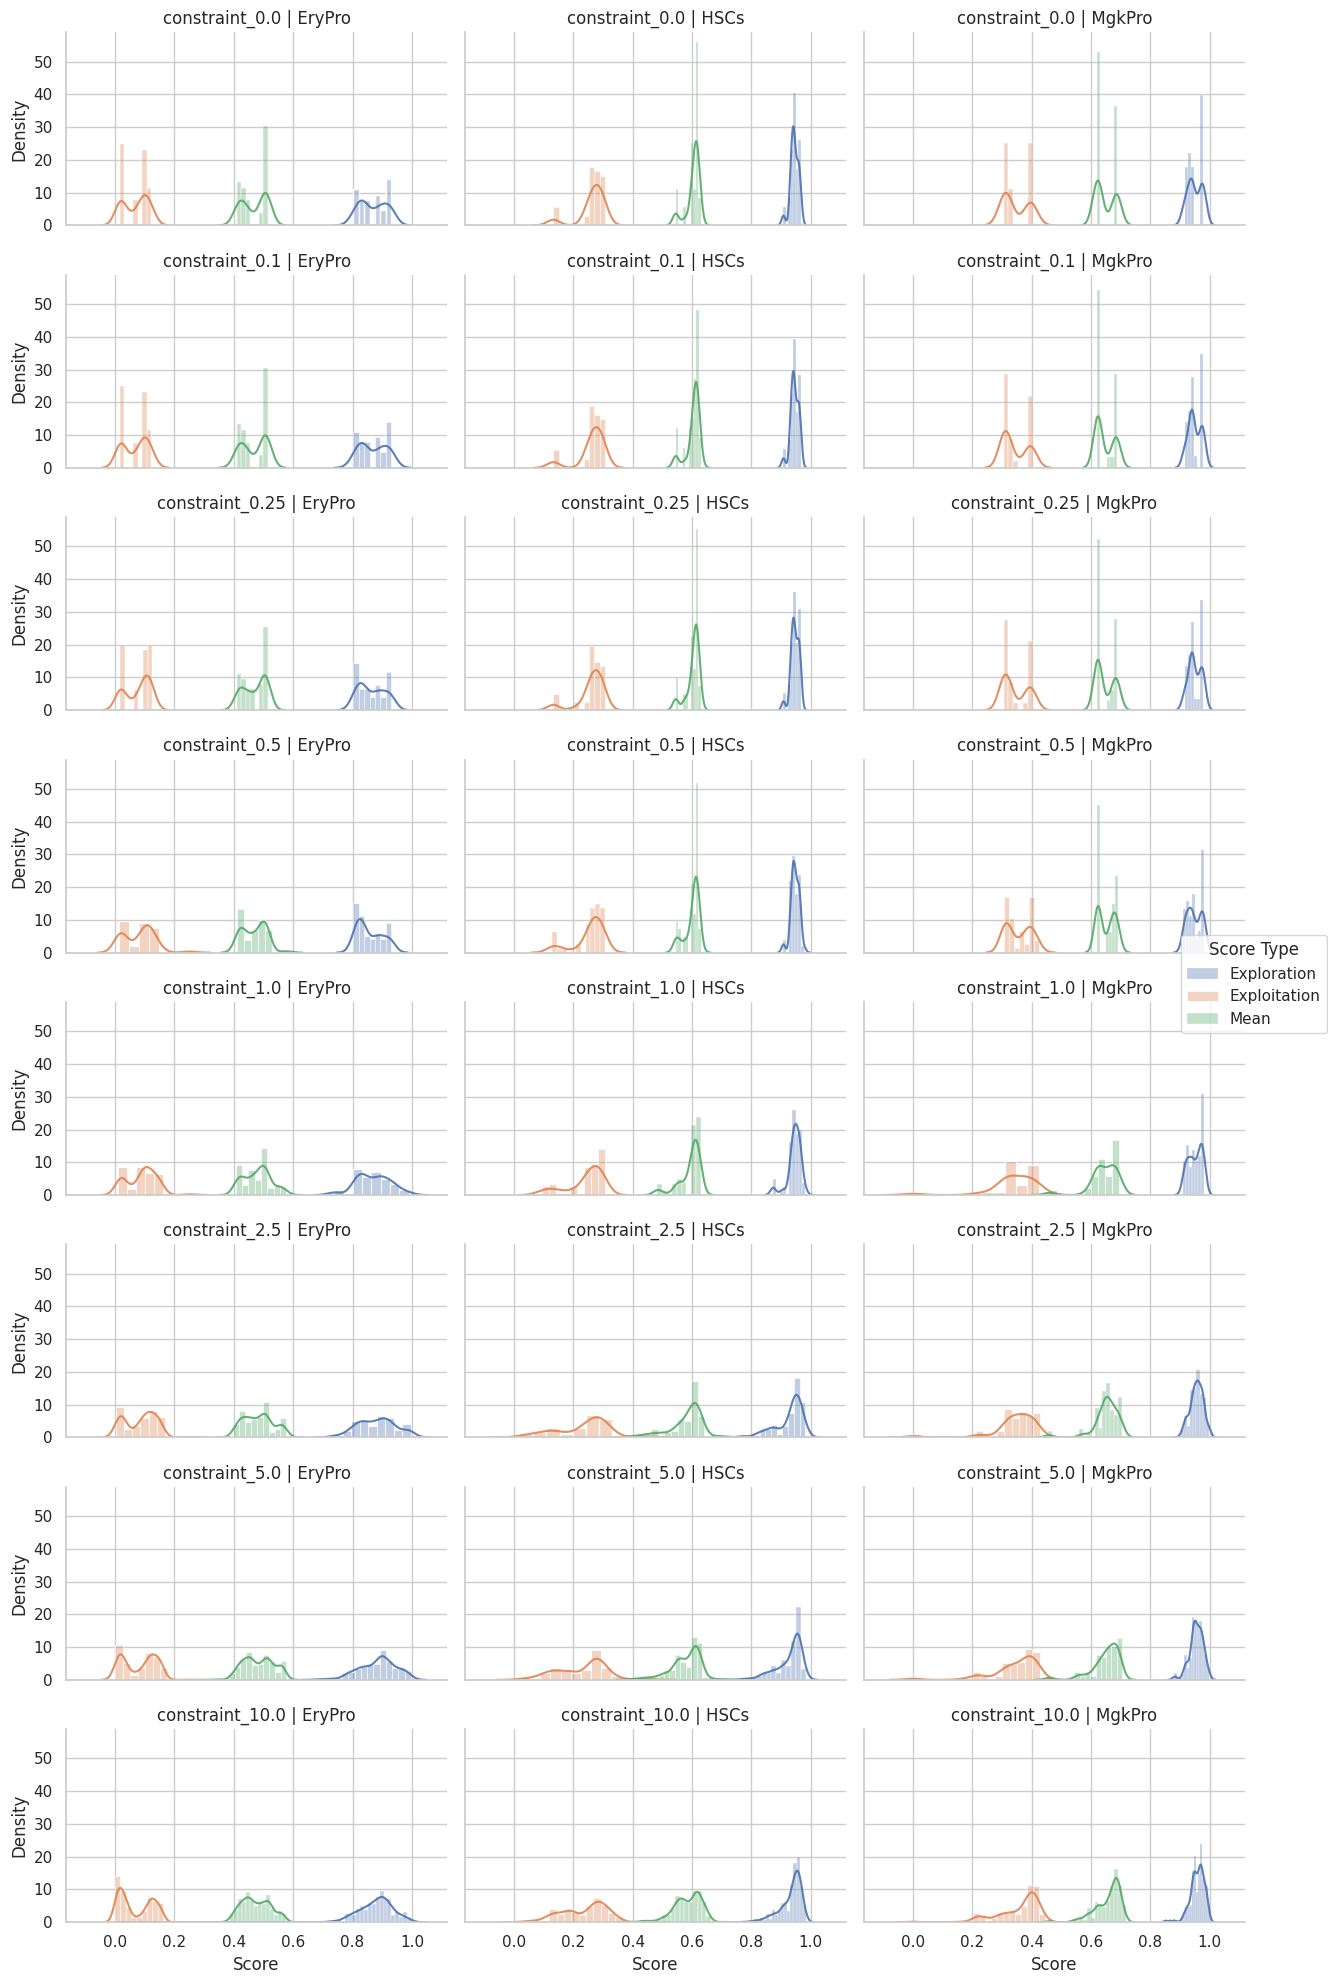

In [322]:
# Build long-format DataFrame for all three score types
long_list = []

for ct, constraints_dict in ct_constrained_results.items():
    for constraint_name, df_filtered in constraints_dict.items():
        temp_df = pd.DataFrame({
            "target_ct": ct,
            "constraint": constraint_name,
            "Exploration": df_filtered["exploration_score"],
            "Exploitation": df_filtered["exploitation_score"],
            "Mean": df_filtered["MRS_mean"]
        })
        # Melt to long format for seaborn
        temp_long = temp_df.melt(
            id_vars=["target_ct", "constraint"],
            var_name="score_type",
            value_name="score"
        )
        long_list.append(temp_long)

score_long = pd.concat(long_list, axis=0).reset_index(drop=True)

# Sort constraints numerically for nicer plotting
score_long["constraint"] = pd.Categorical(
    score_long["constraint"],
    categories=sorted(score_long["constraint"].unique(), key=lambda x: float(x.split("_")[1])),
    ordered=True
)

# FacetGrid: rows = constraints, columns = cell types
g = sns.FacetGrid(
    score_long,
    row="constraint",
    col="target_ct",
    hue="score_type",
    height=2.5,
    aspect=1.5,
    sharex=True,
    sharey=True
)

# Plot histogram
g.map_dataframe(
    sns.histplot,
    x="score",
    stat="density",
    fill=True,
    alpha=0.35,
    common_norm=False
)

# Overlay KDE
g.map_dataframe(
    sns.kdeplot,
    x="score",
    alpha=0.9,
    common_norm=False
)

# Labels & titles
g.set_axis_labels("Score", "Density")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Add legend for score type and move it slightly to the right
g.add_legend(title="Score Type")
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(True)

plt.tight_layout()
plt.show()


### Plot distribution of WMU scores over samples satifying constraints.

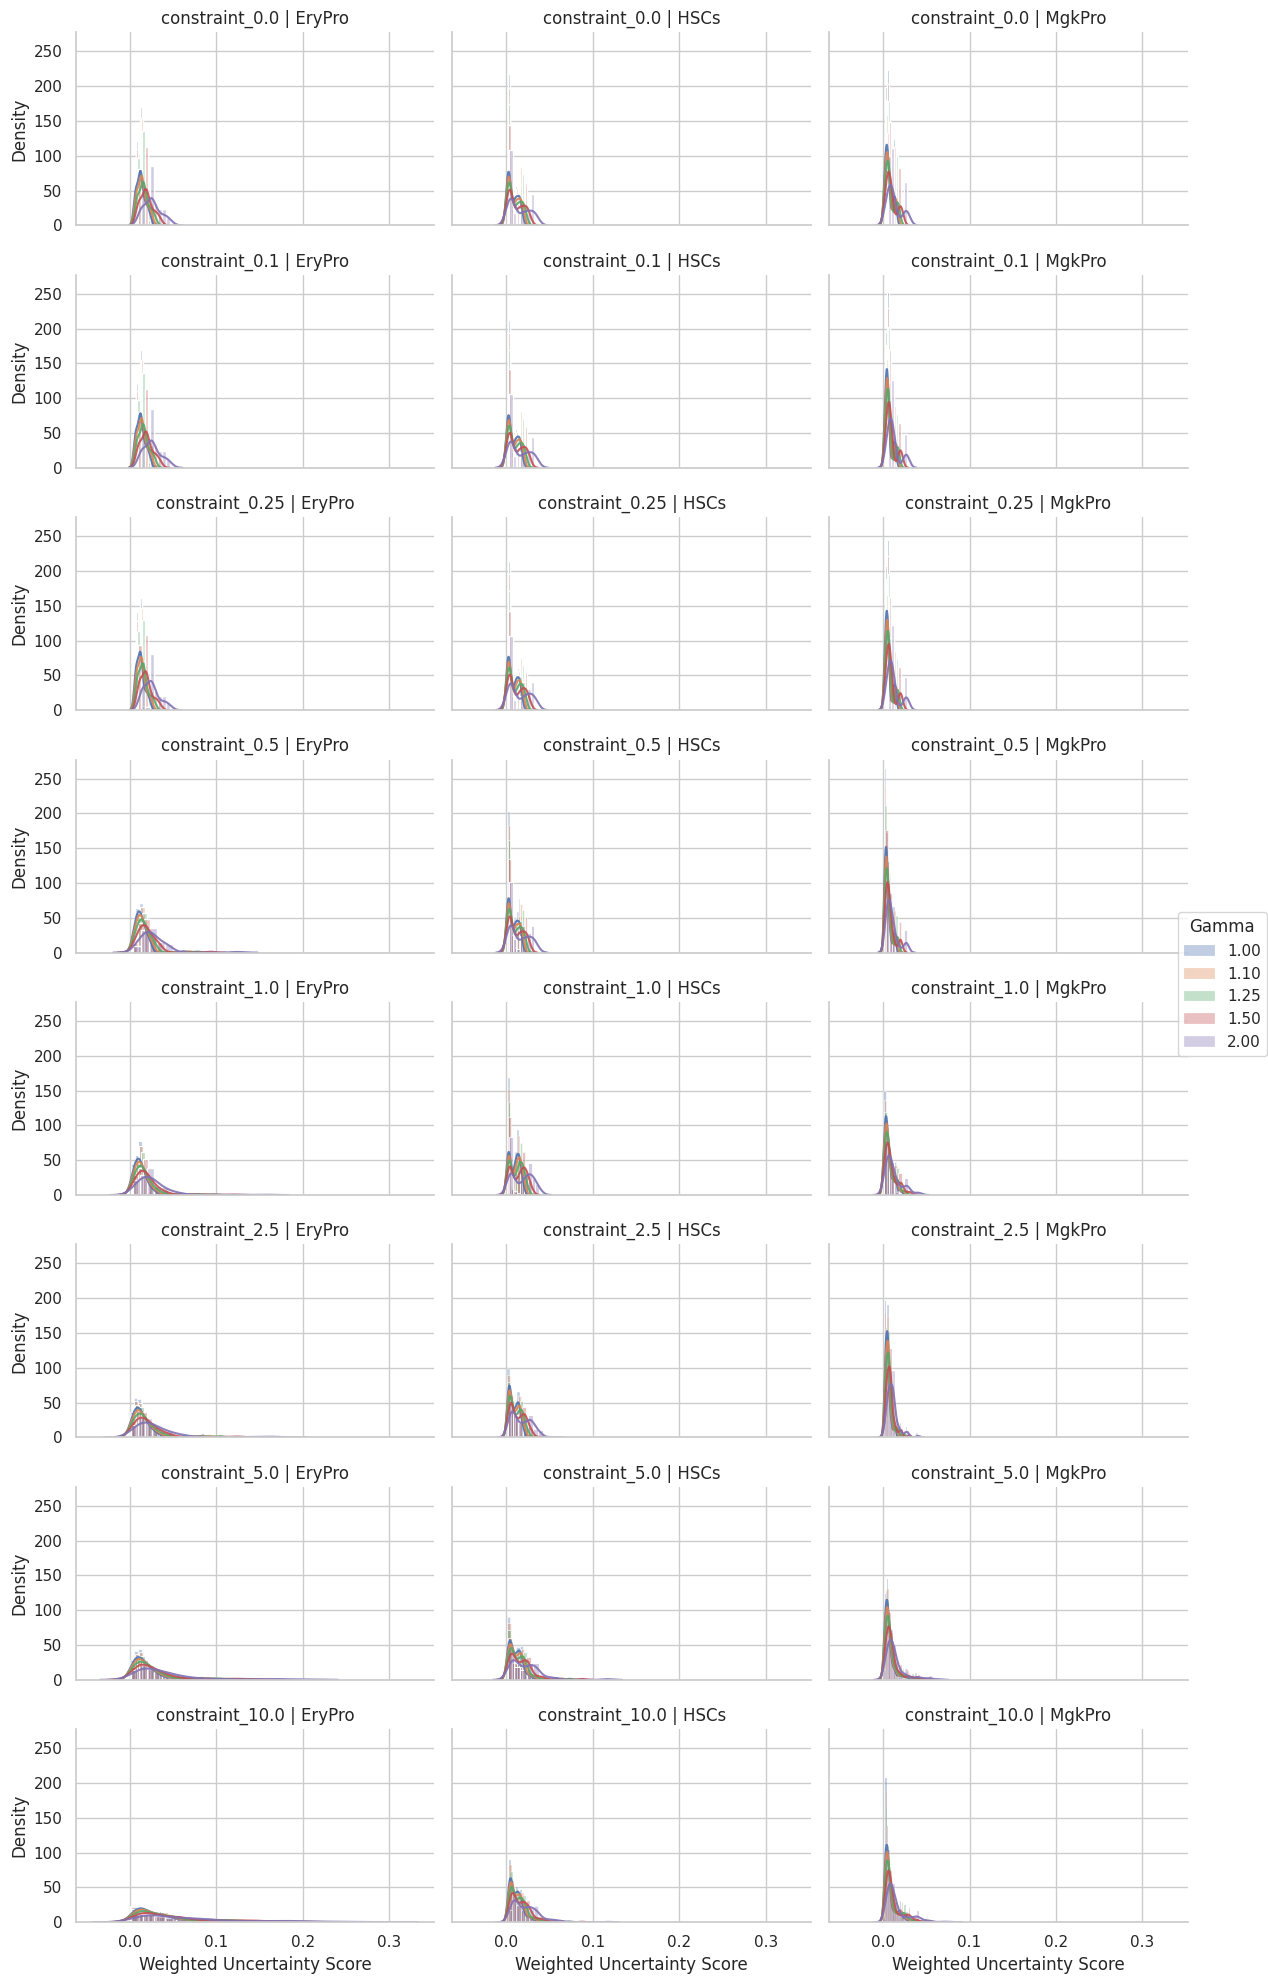

In [323]:
long_list = []

for ct, constraints_dict in ct_constrained_results.items():  # reuse your same ct_constrained_results structure
    for constraint_name, df_filtered in constraints_dict.items():
        temp_df = pd.DataFrame({
            "target_ct": ct,
            "constraint": constraint_name,
            # Extract wmu scores for all gammas in this filtered df
            **{f"wmus_{1+gamma}": df_filtered[f"wmus_{1+gamma}"] for gamma in [0.0, 0.1, 0.25, 0.5, 1.0] if f"wmus_{1+gamma}" in df_filtered.columns}
        })
        # Melt to long format
        temp_long = temp_df.melt(
            id_vars=["target_ct", "constraint"],
            var_name="gamma",
            value_name="wmus"
        )
        # Convert gamma string to float for ordering
        temp_long["gamma"] = temp_long["gamma"].str.replace("wmus_", "").astype(float)
        long_list.append(temp_long)

wmu_long = pd.concat(long_list, axis=0).reset_index(drop=True)

# Sort constraints and gamma values for nice ordering
wmu_long["constraint"] = pd.Categorical(
    wmu_long["constraint"],
    categories=sorted(wmu_long["constraint"].unique(), key=lambda x: float(x.split("_")[1])),
    ordered=True
)
wmu_long["gamma_label"] = wmu_long["gamma"].apply(lambda x: f"{x:.2f}")

# FacetGrid: rows = constraints, columns = cell types
g = sns.FacetGrid(
    wmu_long,
    row="constraint",
    col="target_ct",
    hue="gamma_label",
    height=2.5,
    aspect=1.5,
    sharex=True,
    sharey=True
)

# Histogram
g.map_dataframe(
    sns.histplot,
    x="wmus",
    stat="density",
    fill=True,
    alpha=0.35,
    common_norm=False
)

# KDE
g.map_dataframe(
    sns.kdeplot,
    x="wmus",
    alpha=0.9,
    common_norm=False
)

# Labels & titles
g.set_axis_labels("Weighted Uncertainty Score", "Density")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Legend for gamma
g.add_legend(title="Gamma")
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(True)

plt.tight_layout()
plt.show()


### Select top K solutions according to each criterion.

In [324]:
K = 15

minimize_criteria = ["exploration_score", "exploitation_score", "MRS_mean", "loss"]
maximize_criteria = [c for c in concat_df.columns if c.startswith("wmus")]

all_rows = []

for ct, constraints_dict in ct_constrained_results.items():
    for constraint_name, df_filtered in constraints_dict.items():

        # Minimize scores
        for crit in minimize_criteria:
            if crit not in df_filtered.columns:
                continue
            top_k = df_filtered.nsmallest(K, crit).copy()
            top_k["original_index"] = top_k.index
            top_k["target_ct"] = ct
            top_k["constraint"] = constraint_name
            top_k["criterion"] = f"min_{crit}"
            all_rows.append(top_k)

        # Maximize WMU scores
        for crit in maximize_criteria:
            if crit not in df_filtered.columns:
                continue
            top_k = df_filtered.nlargest(K, crit).copy()
            top_k["original_index"] = top_k.index
            top_k["target_ct"] = ct
            top_k["constraint"] = constraint_name
            top_k["criterion"] = f"max_{crit}"
            all_rows.append(top_k)

# Combine everything
topK_df = pd.concat(all_rows, axis=0).reset_index(drop=True)

# Optional multi-index
topK_df = topK_df.set_index(["target_ct", "constraint", "criterion", "original_index"])

topK_df


740-yp_[µm]  \
target_ct constraint      criterion             original_index                                         
EryPro    constraint_0.0  min_exploration_score EryPro:2026-01-14_12-31-34_4a142648:80      4.483994   
                                                EryPro:2026-01-14_13-09-18_27573f30:109     3.654410   
                                                EryPro:2025-12-20_13-20-55_3ec79f6b:109     3.654410   
                                                EryPro:2025-12-21_07-18-04_c1544962:80      4.815618   
                                                EryPro:2025-12-21_07-27-12_3ef790d1:80      4.815618   
...                                                                                              ...   
MgkPro    constraint_10.0 max_wmus_2.0          MgkPro:2025-12-20_22-55-34_173c1749:93      5.635548   
                                                MgkPro:2025-12-20_22-39-59_76fd6739:93      5.635548   
                                                MgkPro:2025-12-20_13-09-13_9d1a17a0:54      4.000184   
                                                MgkPro:2025-12-20_23-10-06_8f1640ea:42      5.989020   
                                                MgkPro:2025-12-20_22-39-21_c805ecf5:42      5.989020   

                                                                                           mtg_[µm]  \
target_ct constraint      criterion             original_index                                        
EryPro    constraint_0.0  min_exploration_score EryPro:2026-01-14_12-31-34_4a142648:80    45.403290   
                                                EryPro:2026-01-14_13-09-18_27573f30:109   37.826626   
                                                EryPro:2025-12-20_13-20-55_3ec79f6b:109   37.826626   
                                                EryPro:2025-12-21_07-18-04_c1544962:80    44.860510   
                                                EryPro:2025-12-21_07-27-12_3ef790d1:80    44.860510   
...                                                                                             ...   
MgkPro    constraint_10.0 max_wmus_2.0          MgkPro:2025-12-20_22-55-34_173c1749:93    97.757430   
                                                MgkPro:2025-12-20_22-39-59_76fd6739:93    97.757430   
                                                MgkPro:2025-12-20_13-09-13_9d1a17a0:54    78.557810   
                                                MgkPro:2025-12-20_23-10-06_8f1640ea:42   107.640530   
                                                MgkPro:2025-12-20_22-39-21_c805ecf5:42   107.640530   

                                                                                         rhflt3l_[ng_ml]  \
target_ct constraint      criterion             original_index                                             
EryPro    constraint_0.0  min_exploration_score EryPro:2026-01-14_12-31-34_4a142648:80          8.558643   
                                                EryPro:2026-01-14_13-09-18_27573f30:109         9.413566   
                                                EryPro:2025-12-20_13-20-55_3ec79f6b:109         9.413566   
                                                EryPro:2025-12-21_07-18-04_c1544962:80          7.755276   
                                                EryPro:2025-12-21_07-27-12_3ef790d1:80          7.755276   
...                                                                                                  ...   
MgkPro    constraint_10.0 max_wmus_2.0          MgkPro:2025-12-20_22-55-34_173c1749:93         12.665832   
                                                MgkPro:2025-12-20_22-39-59_76fd6739:93         12.665832   
                                                MgkPro:2025-12-20_13-09-13_9d1a17a0:54         19.301422   
                                                MgkPro:2025-12-20_23-10-06_8f1640ea:42         19.972908   
                                                MgkPro:2025-12-20_22-39-21_c805ecf5:42         19.97

## KDE plot of Oxygen distribution.

<Axes: xlabel='o2_[%]', ylabel='Density'>

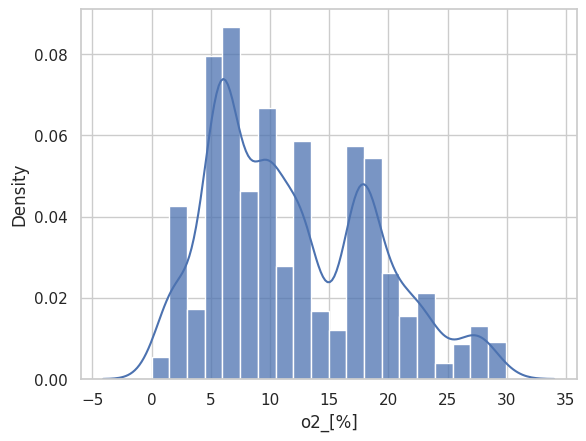

In [325]:
sns.kdeplot(topK_df["o2_[%]"])
sns.histplot(topK_df["o2_[%]"], stat="density")

### KDE plot of number of days.

<Axes: xlabel='days_of_culture', ylabel='Density'>

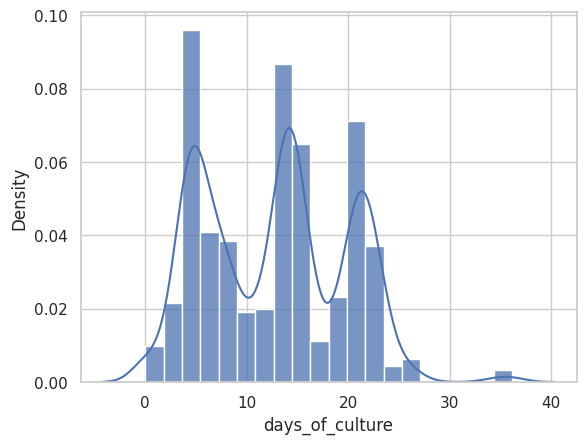

In [326]:
sns.kdeplot(topK_df["days_of_culture"])
sns.histplot(topK_df["days_of_culture"], stat="density")

### Plot distribution of surrogate loss for selected runs.

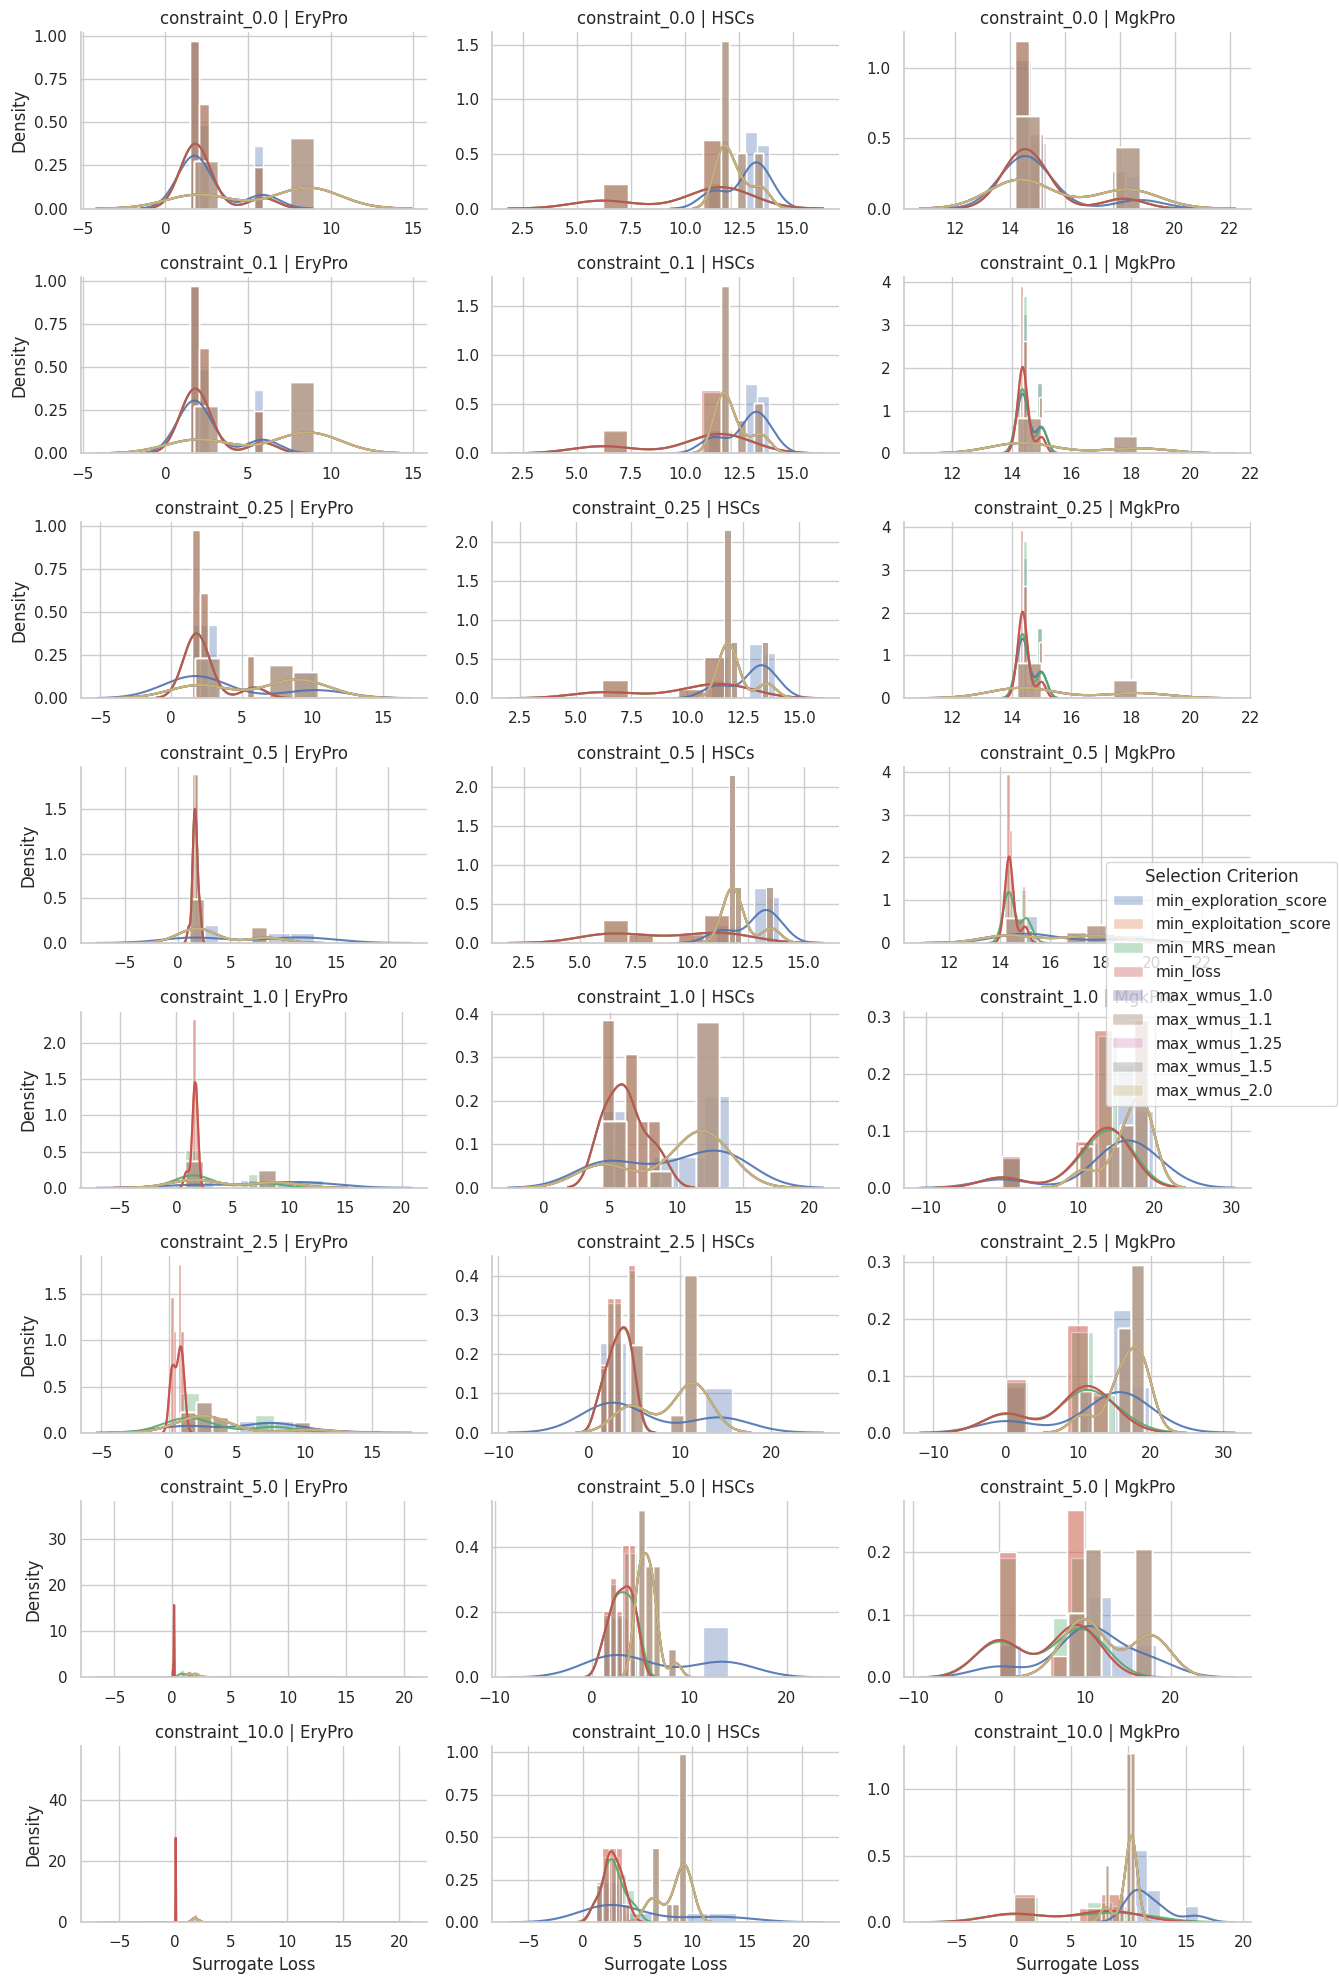

In [327]:
# Reset index so seaborn can use the grouping columns
plot_df = topK_df.reset_index()

# FacetGrid:
# - Columns = cell types
# - Rows = constraints
# - Hue = selection criterion
g = sns.FacetGrid(
    plot_df,
    row="constraint",
    col="target_ct",
    hue="criterion",
    height=2.5,
    aspect=1.4,
    sharex=False,
    sharey=False
)

# Histogram
g.map_dataframe(
    sns.histplot,
    x="loss",
    stat="density",
    fill=True,
    alpha=0.35,
    common_norm=False
)

# KDE overlay
g.map_dataframe(
    sns.kdeplot,
    x="loss",
    alpha=0.9,
    common_norm=False
)

# Labels & titles
g.set_axis_labels("Surrogate Loss", "Density")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Legend
g.add_legend(title="Selection Criterion")
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(True)

plt.tight_layout()
plt.show()


## Saving results.

### Saving updated candidates df.

In [328]:
concat_df.to_csv(
    os.path.join(CANDIDATES_DIR, "candidates_with_eval.csv")
)

### Saving selected samples.

In [329]:
topK_df.to_csv(
    os.path.join(CANDIDATES_DIR, f"top_{K}_candidates.csv")
)

### Write file to run plotting jobs.

In [330]:
OUT_FILE = "../experiments/jobs_selected.txt"
jobs = []
for val in topK_df.index.get_level_values("original_index").unique():
    ct, run, idx = val.split(":")
    if not run.startswith("2026"): continue
    jobs.append(f"{ct} {run} {idx}")
with open(OUT_FILE, "w") as f:
    f.write("\n".join(jobs))

### Select runs based on constraint.

In [331]:
cidxs = concat_df["o2_[%]"].apply(lambda e: e > 20 and e < 21) * concat_df["days_of_culture"].apply(lambda e: e > 10 and e < 21)
constrained_df = concat_df.loc[cidxs]

In [332]:
ct_constrained_results_new = {} 
for target_ct, ct_idxs in concat_df.groupby(by="target_ct").groups.items():
    ct_concat_df = concat_df.loc[ct_idxs]
    ct_constrained_results_new[target_ct] = {
        e: ct_concat_df.iloc[ct_concat_df.loc[:, e].values] for e in ct_concat_df.columns if e.startswith("constraint_")
    }

K = 3

minimize_criteria = ["exploration_score", "exploitation_score", "MRS_mean", "loss"]
maximize_criteria = [c for c in concat_df.columns if c.startswith("wmus")]

all_rows = []

for ct, constraints_dict in ct_constrained_results_new.items():
    for constraint_name, df_filtered in constraints_dict.items():

        # Minimize scores
        for crit in minimize_criteria:
            if crit not in df_filtered.columns:
                continue
            top_k = df_filtered.nsmallest(K, crit).copy()
            top_k["original_index"] = top_k.index
            top_k["target_ct"] = ct
            top_k["constraint"] = constraint_name
            top_k["criterion"] = f"min_{crit}"
            all_rows.append(top_k)

        # Maximize WMU scores
        for crit in maximize_criteria:
            if crit not in df_filtered.columns:
                continue
            top_k = df_filtered.nlargest(K, crit).copy()
            top_k["original_index"] = top_k.index
            top_k["target_ct"] = ct
            top_k["constraint"] = constraint_name
            top_k["criterion"] = f"max_{crit}"
            all_rows.append(top_k)

# Combine everything
topK_df = pd.concat(all_rows, axis=0).reset_index(drop=True)

# Optional multi-index
topK_df = topK_df.set_index(["target_ct", "constraint", "criterion", "original_index"])

topK_df


740-yp_[µm]  \
target_ct constraint      criterion              original_index                                         
EryPro    constraint_0.0  min_exploration_score  EryPro:2026-01-14_12-31-34_4a142648:80      4.483994   
                                                 EryPro:2026-01-14_13-09-18_27573f30:109     3.654410   
                                                 EryPro:2025-12-20_13-20-55_3ec79f6b:109     3.654410   
                          min_exploitation_score EryPro:2025-12-21_07-18-04_c1544962:80      4.815618   
                                                 EryPro:2025-12-21_07-27-12_3ef790d1:80      4.815618   
...                                                                                               ...   
MgkPro    constraint_10.0 max_wmus_1.5           MgkPro:2025-12-20_12-57-34_41731295:93      5.646688   
                                                 MgkPro:2025-12-20_22-51-39_14c8ac72:93      5.811281   
                          max_wmus_2.0           MgkPro:2026-01-14_13-02-23_8c029ec7:93      5.646688   
                                                 MgkPro:2025-12-20_12-57-34_41731295:93      5.646688   
                                                 MgkPro:2025-12-20_22-51-39_14c8ac72:93      5.811281   

                                                                                            mtg_[µm]  \
target_ct constraint      criterion              original_index                                        
EryPro    constraint_0.0  min_exploration_score  EryPro:2026-01-14_12-31-34_4a142648:80    45.403290   
                                                 EryPro:2026-01-14_13-09-18_27573f30:109   37.826626   
                                                 EryPro:2025-12-20_13-20-55_3ec79f6b:109   37.826626   
                          min_exploitation_score EryPro:2025-12-21_07-18-04_c1544962:80    44.860510   
                                                 EryPro:2025-12-21_07-27-12_3ef790d1:80    44.860510   
...                                                                                              ...   
MgkPro    constraint_10.0 max_wmus_1.5           MgkPro:2025-12-20_12-57-34_41731295:93    99.662230   
                                                 MgkPro:2025-12-20_22-51-39_14c8ac72:93   106.800580   
                          max_wmus_2.0           MgkPro:2026-01-14_13-02-23_8c029ec7:93    99.662230   
                                                 MgkPro:2025-12-20_12-57-34_41731295:93    99.662230   
                                                 MgkPro:2025-12-20_22-51-39_14c8ac72:93   106.800580   

                                                                                          rhflt3l_[ng_ml]  \
target_ct constraint      criterion              original_index                                             
EryPro    constraint_0.0  min_exploration_score  EryPro:2026-01-14_12-31-34_4a142648:80          8.558643   
                                                 EryPro:2026-01-14_13-09-18_27573f30:109         9.413566   
                                                 EryPro:2025-12-20_13-20-55_3ec79f6b:109         9.413566   
                          min_exploitation_score EryPro:2025-12-21_07-18-04_c1544962:80          7.755276   
                                                 EryPro:2025-12-21_07-27-12_3ef790d1:80          7.755276   
...                                                                                                   ...   
MgkPro    constraint_10.0 max_wmus_1.5           MgkPro:2025-12-20_12-57-34_41731295:93         12.645080   
                                                 MgkPro:2025-12-20_22-51-39_14c8ac72:93         16.532757   
                          max_wmus_2.0           MgkPro:2026-01-14_13-02-23_8c029ec7:93         12.645080   
                                                 MgkPro:2025-12-20_12-57-34_41731295:93         12.645080   
                                                 MgkPro:2025-12

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this war

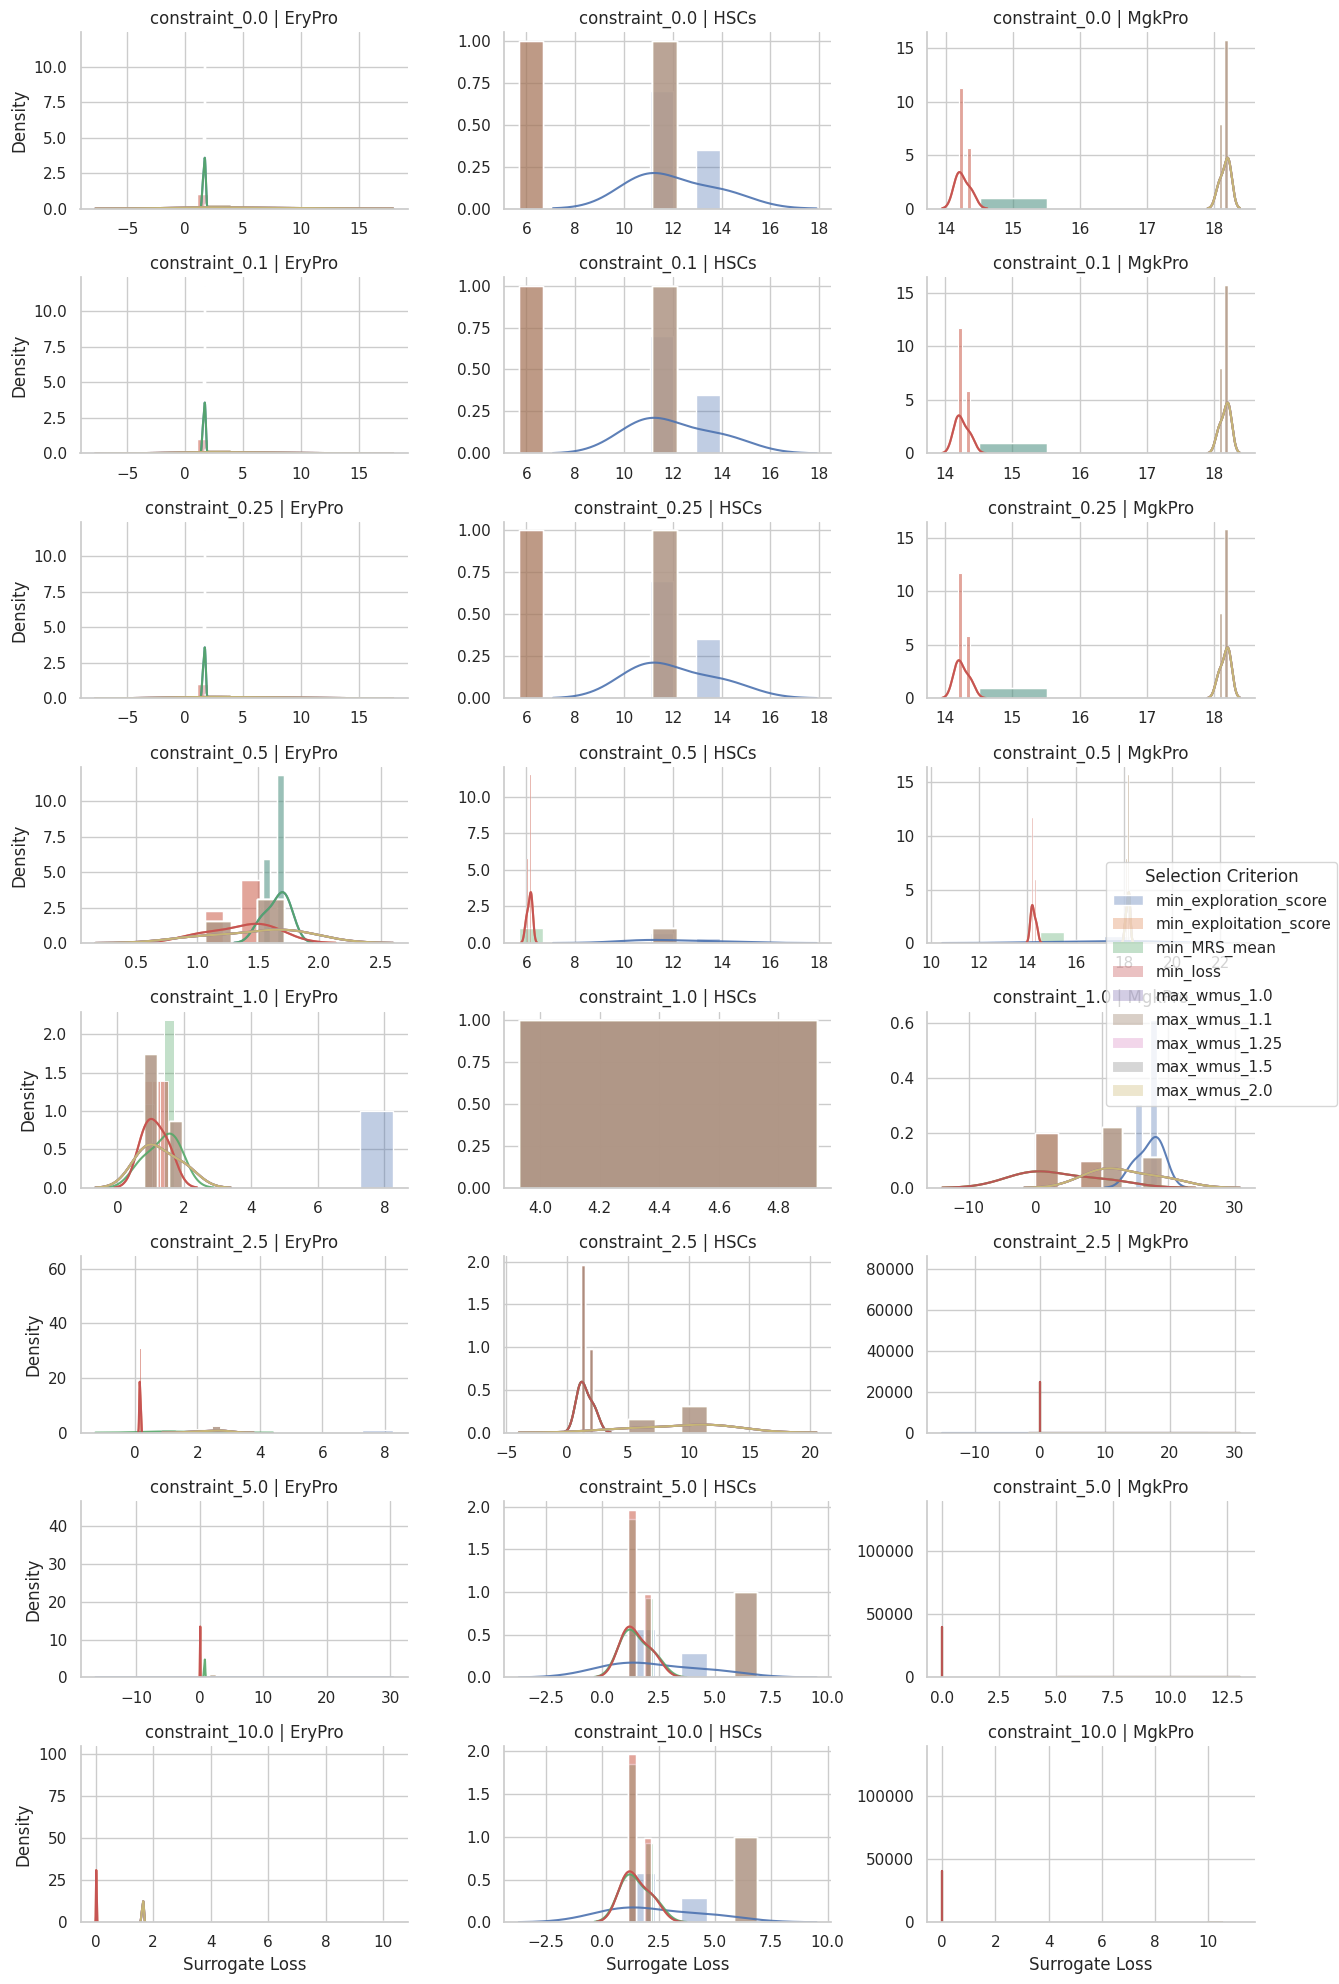

In [333]:
# Reset index so seaborn can use the grouping columns
plot_df = topK_df

# FacetGrid:
# - Columns = cell types
# - Rows = constraints
# - Hue = selection criterion
plot_df["criterion"] = plot_df.index.get_level_values("criterion")
plot_df["constraint"] = plot_df.index.get_level_values("constraint")
plot_df["target_ct"] = plot_df.index.get_level_values("target_ct")
g = sns.FacetGrid(
    plot_df,
    row="constraint",
    col="target_ct",
    hue="criterion",
    height=2.5,
    aspect=1.4,
    sharex=False,
    sharey=False
)

# Histogram
g.map_dataframe(
    sns.histplot,
    x="loss",
    stat="density",
    fill=True,
    alpha=0.35,
    common_norm=False
)

# KDE overlay
g.map_dataframe(
    sns.kdeplot,
    x="loss",
    alpha=0.9,
    common_norm=False
)

# Labels & titles
g.set_axis_labels("Surrogate Loss", "Density")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Legend
g.add_legend(title="Selection Criterion")
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(True)

plt.tight_layout()
plt.show()


In [334]:
from scipy.special import log_softmax

TARGET_PROPS_DICTIONARY = {
    "HSCs": [0.07, 0.07, 0.00, 0.00, 0.07, 0.01, 0.07, 0.07, 0.00, 0.07, 0.07, 0.00, 0.21, 0.07, 0.07, 0.07, 0.00, 0.01, 0.07],
    "MgkPro": [0.05, 0.05, 0.00, 0.00, 0.05, 0.01, 0.01, 0.05, 0.00, 0.05, 0.05, 0.00, 0.05, 0.05, 0.05, 0.05, 0.42, 0.01, 0.05],
    "EryPro": [0.05, 0.05, 0.00, 0.00, 0.05, 0.01, 0.01, 0.05, 0.42, 0.05, 0.05, 0.00, 0.05, 0.05, 0.05, 0.05, 0.0, 0.01, 0.05],
}

for k, v in TARGET_PROPS_DICTIONARY.items():
    v = np.array(v)
    lmin = -np.sum(v*log_softmax(v, axis=-1), axis=-1)
    print(k, lmin)

HSCs 2.900097400197875
MgkPro 2.7973201970126027
EryPro 2.7973201970126027


## Analyse HSCs results.

<Axes: xlabel='HSCs_prop', ylabel='Density'>

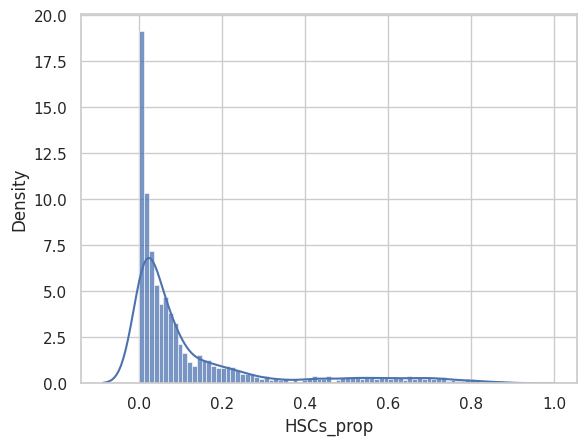

In [335]:
target_ct = "HSCs"
prop_col = f"{target_ct}_prop"
target_ct_df = concat_df.loc[concat_df["target_ct"] == target_ct].sort_values(prop_col, ascending=False)
sns.histplot(target_ct_df, x=prop_col, stat="density")
sns.kdeplot(target_ct_df, x=prop_col)


### Threshold results by ct prop.

In [336]:
min_ct_prop = 0.15
target_ct_df = target_ct_df.loc[target_ct_df[prop_col] > min_ct_prop]
target_ct_df

,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],...,constraint_0.5,constraint_1.0,constraint_2.5,constraint_5.0,constraint_10.0,wmus_1.0,wmus_1.1,wmus_1.25,wmus_1.5,wmus_2.0
sample_id,,,,,,,,,,,,,,,,,,,,,
HSCs:2025-12-19_19-46-32_d0ad37e2:92,6.697509,64.686670,7.023659,5.958300,0.000000,0.000000,1457.246300,0.000000,0.313127,92.002040,...,False,False,False,False,False,0.002720,0.002993,0.003401,0.004081,0.005441
HSCs:2025-12-20_00-07-12_451268d2:92,6.697509,64.686670,7.023659,5.958300,0.000000,0.000000,1457.246300,0.000000,0.313127,92.002040,...,False,False,False,False,False,0.002720,0.002993,0.003401,0.004081,0.005441
HSCs:2025-12-20_21-22-39_53d14a57:46,7.722965,54.613260,6.810053,284.809330,1.127396,78.522310,561.685400,0.000000,0.000000,0.043065,...,False,False,False,False,False,0.008482,0.009330,0.010603,0.012723,0.016964
HSCs:2025-12-20_21-20-45_b6767691:46,7.722965,54.613260,6.810053,284.809330,1.127396,78.522310,561.685400,0.000000,0.000000,0.043065,...,False,False,False,False,False,0.008482,0.009330,0.010603,0.012723,0.016964
HSCs:2025-12-20_18-10-25_b1ba3bf7:46,7.722965,54.613260,6.810053,284.809330,1.127396,78.522310,561.685400,0.000000,0.000000,0.043065,...,False,False,False,False,False,0.008482,0.009330,0.010603,0.012723,0.016964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HSCs:2026-01-14_13-23-24_cae8f867:9,5.973213,178.925350,4.156714,14.647817,0.638817,811.423460,3.771319,1.301402,0.000000,0.362183,...,False,False,False,False,False,0.005743,0.006317,0.007179,0.008614,0.011486
HSCs:2025-12-19_20-04-11_45ced38c:4,5.433438,13.365983,16.140450,8.515056,3.511730,56.530254,1899.404200,0.000000,38.709682,0.112068,...,False,False,False,False,False,0.060179,0.066196,0.075223,0.090268,0.120357
HSCs:2025-12-19_23-57-34_f3ac5fd8:4,5.433438,13.365983,16.140450,8.515056,3.511730,56.530254,1899.404200,0.000000,38.709682,0.112068,...,False,False,False,False,False,0.060179,0.066196,0.075223,0.090268,0.120357


### Read configurations dictionaries.

In [337]:

def flatten_conf(conf_dict):
    return_dict = {}
    for key, value in conf_dict.items():
        if isinstance(value, dict):
            update_dict = {f"{key}:{k}": v for k, v in flatten_conf(value).items()}
        else:
            update_dict = {key: value}
        return_dict.update(update_dict)
    return return_dict

In [338]:
from collections import defaultdict

# prepare paths for target cell type
target_ct_dir = os.path.join(CANDIDATES_DIR, target_ct)
runs = os.listdir(target_ct_dir)
runs_dir = [os.path.join(target_ct_dir, run) for run in runs]

# prepare store for results
df_idx = []
conf_df = defaultdict(list)
fwd_rdict = {}
inv_rdict = {}

# define progress bar
pbar = tqdm(range(len(runs_dir)))

# iterate over the runs
for idx, rdir in enumerate(runs_dir):
    # skip not directory
    if not os.path.isdir(rdir):
        continue

    # update progress bar
    run_id = runs[idx]
    pbar.set_description(
        f"{run_id=}"
    )
    pbar.update()

    # configuration file
    with open(os.path.join(rdir, "config.yaml"), "r") as fb:
        conf_dict = yaml.safe_load(fb)
    fconf_dict = flatten_conf(conf_dict)

    # update configuration data dictionary and index
    for k, v in fconf_dict.items():
        conf_df[k].append(v)
    df_idx.append(run_id)

    # load arrays
    fwd_rdict[run_id] = np.load(os.path.join(rdir, "fwd_results.npz"))
    inv_rdict[run_id] = np.load(os.path.join(rdir, "inverse_results.npz"))

# create config data frame
conf_df = pd.DataFrame(
    conf_df,
    index=pd.Index(df_idx, name="run_id"),
)
conf_df

run_id='2025-12-21_08-16-18_c37e32de':   3%|▎         | 3/96 [00:00<00:07, 12.06it/s]

run_id='2025-12-21_08-40-01_844a7d31':  99%|█████████▉| 95/96 [00:15<00:00,  6.31it/s]

,forward_model:num_time_steps,forward_model:solver_kwargs:method,loss_guidance:fix_noise,loss_guidance:num_forward_pass_per_sample,loss_guidance:regularization,loss_guidance:reg_strength,loss_guidance:n_time_steps_forward_model,loss_guidance:solver_kwargs_forward_model:method,non_linearity:non_linearity_id,non_linearity:non_linearity_kwargs,...,sampling:N,sampling:num_time_steps,sampling:solver_kwargs:method,sampling:sde_sampling,scheduler:scheduler_id,scheduler:scheduler_kwargs:lambda_val,scheduler:scheduler_kwargs:lmin,scheduler:scheduler_kwargs:lmax,scheduler:scheduler_kwargs:gamma,optimized_metric
run_id,,,,,,,,,,,,,,,,,,,,,
2025-12-20_21-20-54_e6b778ac,1000,euler,True,350,None,0.0,50,euler,relu,None,...,125,500,euler,False,reciprocal,3.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
2025-12-20_00-02-56_e826cc9b,1000,euler,True,350,None,0.0,50,euler,relu,None,...,125,500,euler,False,constant,3.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
2025-12-21_08-16-18_c37e32de,1000,euler,True,350,None,0.0,50,euler,relu,None,...,125,100,euler,False,exp-decay,7.0,0.0,10.0,2.0,all_conditions_wasserstein_distance
2025-12-21_08-26-42_ab373cd8,1000,euler,True,350,None,0.0,50,euler,relu,None,...,125,200,euler,False,exp-decay,5.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
2025-12-21_08-23-12_04ebe959,1000,euler,True,350,None,0.0,50,euler,relu,None,...,125,500,euler,False,exp-decay,3.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-14_13-20-46_d0c2bc85,1000,euler,True,350,None,0.0,50,euler,relu,None,...,125,100,euler,False,reciprocal,NaN,0.0,5.0,1.0,all_conditions_wasserstein_distance
2025-12-20_21-20-45_b6767691,1000,euler,True,350,None,0.0,50,euler,relu,None,...,125,100,euler,False,reciprocal,1.0,0.0,10.0,1.0,all_conditions_wasserstein_distance
2025-12-19_19-50-48_3d025d71,1000,euler,True,350,None,0.0,50,euler,relu,None,...,125,500,euler,False,constant,7.0,0.0,10.0,1.0,all_conditions_wasserstein_distance


### 

In [339]:
target_ct_df["run_id"] = target_ct_df.index.map(lambda e: e.split(":")[1])
target_ct_df = target_ct_df.join(conf_df, on="run_id")

/tmp/ipykernel_3813120/124219878.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_ct_df["run_id"] = target_ct_df.index.map(lambda e: e.split(":")[1])


ValueError: columns overlap but no suffix specified: Index(['forward_model:num_time_steps', 'forward_model:solver_kwargs:method',
       'loss_guidance:fix_noise', 'loss_guidance:num_forward_pass_per_sample',
       'loss_guidance:regularization', 'loss_guidance:reg_strength',
       'loss_guidance:n_time_steps_forward_model',
       'loss_guidance:solver_kwargs_forward_model:method',
       'non_linearity:non_linearity_id', 'non_linearity:non_linearity_kwargs',
       'paths:perturbation_prediction_path', 'paths:ct_classifier_path',
       'paths:prior_flow_path', 'paths:dump_dir', 'run:random_seed',
       'sampling:target_cell_type', 'sampling:N', 'sampling:num_time_steps',
       'sampling:solver_kwargs:method', 'sampling:sde_sampling',
       'scheduler:scheduler_id', 'scheduler:scheduler_kwargs:lambda_val',
       'scheduler:scheduler_kwargs:lmin', 'scheduler:scheduler_kwargs:lmax',
       'scheduler:scheduler_kwargs:gamma', 'optimized_metric'],
      dtype='object')

KeyError: 'sampling:mask_gradients'

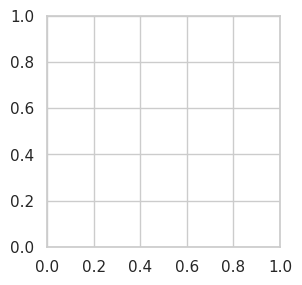

In [ ]:
colored_histogram(
    target_ct_df,
    "sampling:mask_gradients",
    prop_col
)

/tmp/ipykernel_3813120/446896739.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


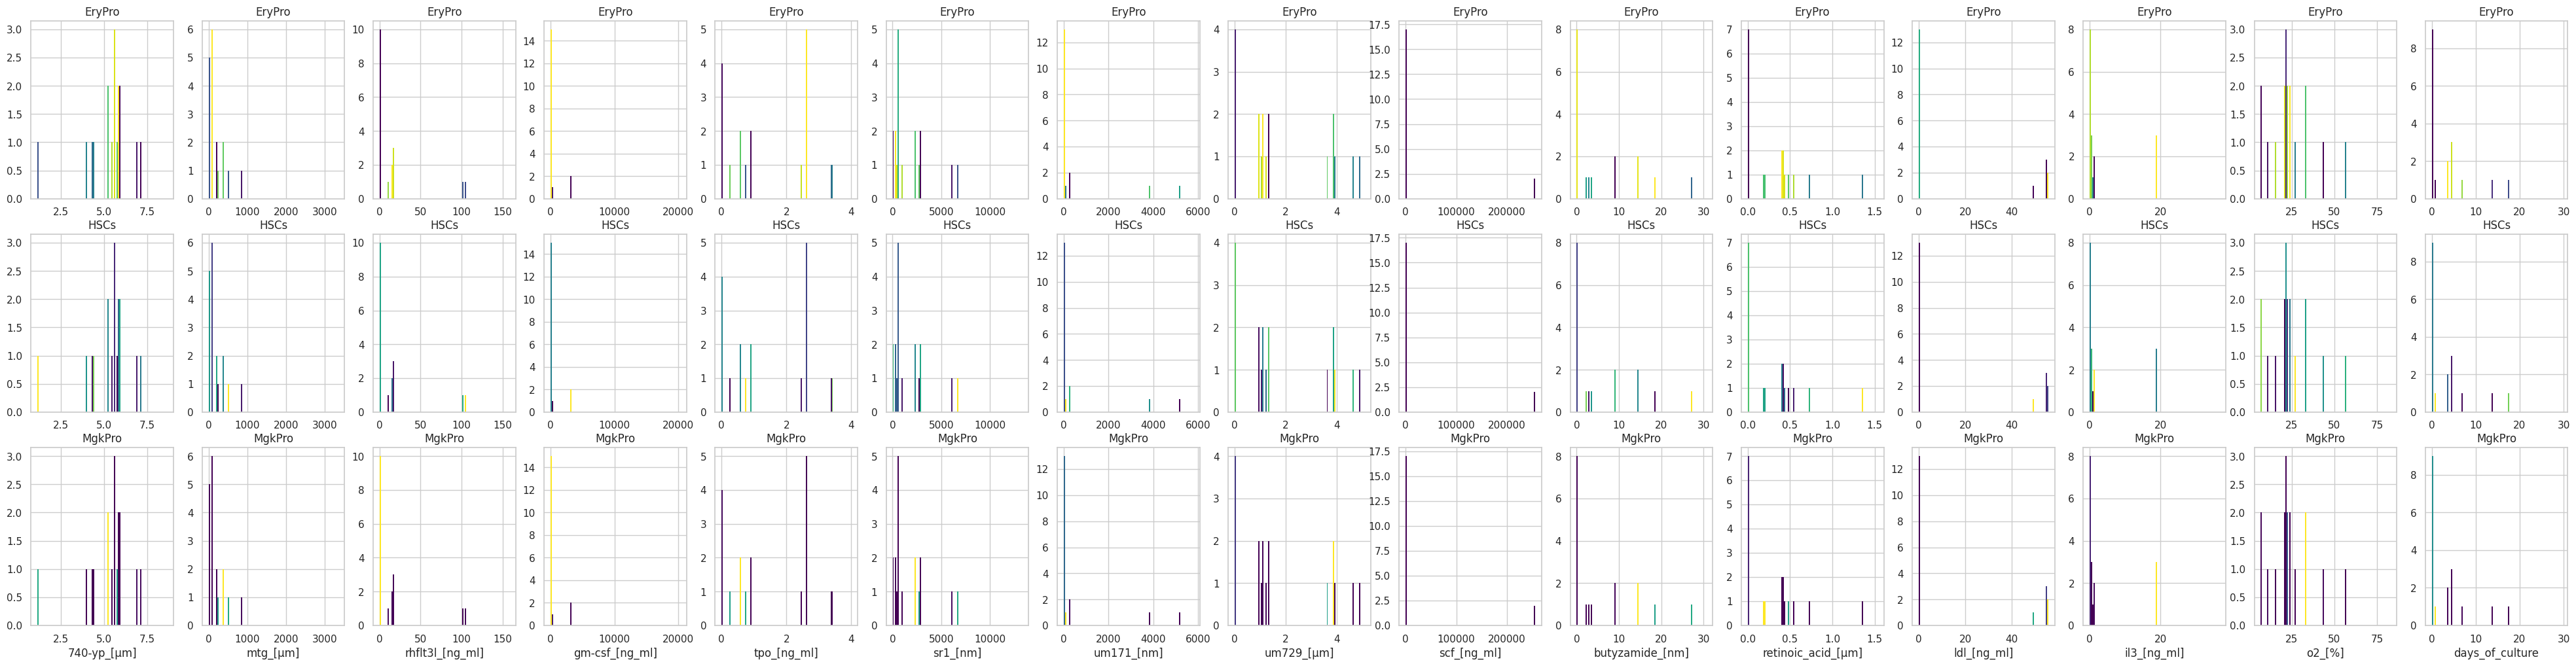

In [ ]:
bins=100
# Aggregation function
agg_funcs = {
    "mean": np.mean,
    "median": np.median,
    "sum": np.sum,
    "min": np.min,
    "max": np.max,
}
agg = "mean"
agg_func = agg_funcs[agg]
cmap_name="viridis"

# Seaborn styling
sns.set_theme(style="whitegrid")


protocol_columns = annotation_config["protocol_columns"]
fig, ax = plt.subplots(nrows=len(cell_types), ncols=len(protocol_columns), figsize=(50, 12))

for idx, ct in enumerate(cell_types):
    ct_ax = ax[idx]

    target_ct_df = concat_df.loc[concat_df["target_ct"] == target_ct].sort_values(prop_col, ascending=False)
    min_ct_prop = 0.15
    target_ct_df = target_ct_df.loc[target_ct_df[prop_col] > min_ct_prop]
    # Histogram
    c = target_ct_df[f"{ct}_prop"].values

    for cidx, col in enumerate(protocol_columns):
        x = target_ct_df[col].values
        # Histogram
        counts, bin_edges = np.histogram(x, bins=bins)
        bin_ids = np.digitize(x, bin_edges) - 1
        # Aggregate color column per bin
        bin_color = np.array([
            agg_func(c[bin_ids == i]) if np.any(bin_ids == i) else np.nan
            for i in range(len(bin_edges) - 1)
        ])
        cmap = cm.get_cmap(cmap_name)
        norm = colors.Normalize(
            vmin=np.nanmin(bin_color),
            vmax=np.nanmax(bin_color)
        )

        # Plot
        ct_ax[cidx].bar(
            bin_edges[:-1],
            counts,
            width=np.diff(bin_edges),
            align="edge",
            color=cmap(norm(bin_color)),
            edgecolor="none"
        )
        ct_ax[cidx].set_title(ct)
        if idx == len(cell_types) - 1:
            ct_ax[cidx].set_xlabel(col)


In [ ]:
UNIQUE_CONC_H5AD_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/unique_concentrations_adata.h5ad"

adata_conc = sc.read_h5ad(UNIQUE_CONC_H5AD_PATH)
adata_conc

transformed_data_conc_df = pd.DataFrame(
    adata_conc.X,
    columns=adata_conc.var_names,
    index=adata_conc.obs.index
)
data_conc_df = map_df(transformed_data_conc_df, icolumn2tranform)
data_conc_df
data_conc_max = data_conc_df.max(0)


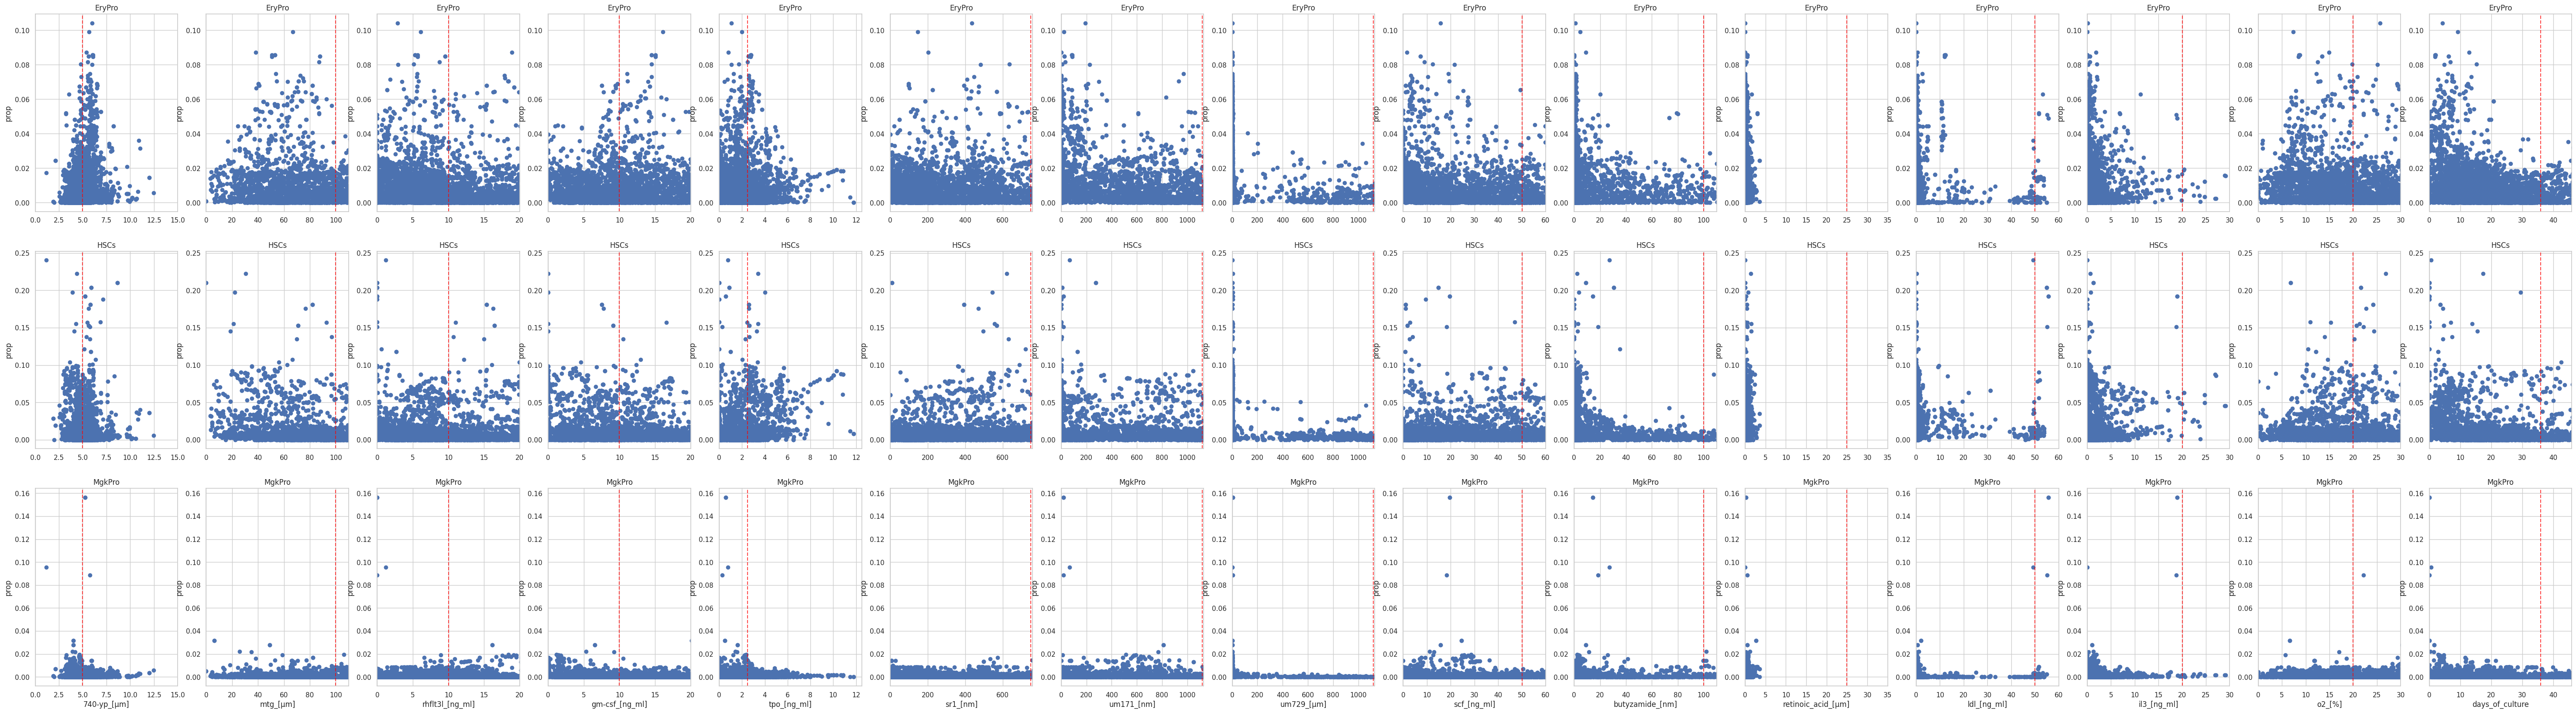

In [ ]:
bins=100
# Aggregation function
agg_funcs = {
    "mean": np.mean,
    "median": np.median,
    "sum": np.sum,
    "min": np.min,
    "max": np.max,
}
agg = "mean"
agg_func = agg_funcs[agg]
cmap_name="viridis"
margin = 10.0

# Seaborn styling
sns.set_theme(style="whitegrid")


protocol_columns = annotation_config["protocol_columns"]
fig, ax = plt.subplots(nrows=len(cell_types), ncols=len(protocol_columns), figsize=(75, 20))

for idx, ct in enumerate(cell_types):
    ct_ax = ax[idx]

    target_ct_df = concat_df.loc[concat_df["target_ct"] == target_ct].sort_values(prop_col, ascending=False)
    min_ct_prop = 0.15
    # target_ct_df = target_ct_df.loc[target_ct_df[f"{ct}_prop"] > min_ct_prop]
    # Histogram
    y = target_ct_df[f"{ct}_prop"].values

    for cidx, col in enumerate(protocol_columns):
        x = target_ct_df[col].values
        # Plot
        ct_ax[cidx].scatter(
            x,
            y,
        )
        ct_ax[cidx].set_title(ct)
        ct_ax[cidx].set_ylabel("prop")
        if idx == len(cell_types) - 1:
            ct_ax[cidx].set_xlabel(col)

        max_val = data_conc_max[col]
        ct_ax[cidx].set_xlim(0, max_val + margin)  # dynamic x-axis cap
        ct_ax[cidx].axvline(x=max_val, color="red", linestyle="--", alpha=0.7)
